#### CONSTANTS

In [1]:
import os
import pandas as pd
import regex as re
import utils as ut
import importlib as il
import numpy as np
import matplotlib.pyplot as plt
from functools import reduce

In [2]:
METADATA = ["match","Date","season","Div","HomeTeam","AwayTeam","FTHG","FTAG","label"]

In [3]:
PATH_GRAPHS = 'F:\TFG\conference\graphs\\v2\\'

In [4]:
PATH_LOGS = 'F:\TFG\code\\framework\logs\mobaxterm\\'
EXPERIMENTS_FOLDER = PATH_LOGS+'experiments_v2.2'+'\\'
EXPERIMENTS_FOLDER_RPS = PATH_LOGS+'experiments_v2.2_rps'+'\\'

In [5]:
rps_exp = ['tabnet_own_comp_rs_unsup_rps']
normal_exp = ['own_original_simp_fac_ss','tabnet_own_simp_ss_sup','own_top1_adv_comp_fac_ss_miv2','tabnet_owntop1_comp_ss_sup','own_original_comp_bal_fac_ss']
top_experiments = rps_exp+normal_exp
paper_exp = ['lgbm_top1_rs','tabnet_paper_ss_unsup']

#### Processing Logits

In [6]:
logits_filenames = [ file for file in os.listdir(EXPERIMENTS_FOLDER) if 'logits' in file ]
logits_filenames_rps = [ file for file in os.listdir(EXPERIMENTS_FOLDER_RPS) if 'logits' in file ]
logits_filenames

['lgbm_top1_rs_logits.csv',
 'lgbm_top1_ss_logits.csv',
 'own_original_comp_bal_fac_ss_logits.csv',
 'own_original_comp_fac_ss_logits.csv',
 'own_original_simp_fac_ss_logits.csv',
 'own_top1_adv_comp_fac_ss_logits.csv',
 'own_top1_adv_comp_fac_ss_miv2_logits.csv',
 'own_top1_comp_fac_ss_logits.csv',
 'tabnet_owntop1_adv_comp_ss_sup_logits.csv',
 'tabnet_owntop1_comp_ss_sup_logits.csv',
 'tabnet_own_comp_rs_unsup_logits.csv',
 'tabnet_own_comp_rs_unsup_rps_logits.csv',
 'tabnet_own_comp_ss_sup_logits.csv',
 'tabnet_own_simp_ss_sup_logits.csv',
 'tabnet_own_simp_ss_unsup_logits.csv',
 'tabnet_paper_ss_unsup_logits.csv']

In [7]:
logitsDF = { name[:-(4+7)]:ut.read_data(EXPERIMENTS_FOLDER + name) for name in logits_filenames if (name[:-(4+7)] in normal_exp+paper_exp)}
logitsDF_rps = { name[:-(4+7)]:ut.read_data(EXPERIMENTS_FOLDER_RPS + name) for name in logits_filenames_rps if (name[:-(4+7)] in rps_exp)}
logitsDF.update(**logitsDF_rps)
logitsDF.keys()

dict_keys(['lgbm_top1_rs', 'own_original_comp_bal_fac_ss', 'own_original_simp_fac_ss', 'own_top1_adv_comp_fac_ss_miv2', 'tabnet_owntop1_comp_ss_sup', 'tabnet_own_simp_ss_sup', 'tabnet_paper_ss_unsup', 'tabnet_own_comp_rs_unsup_rps'])

In [8]:
logits_merged = ut.merge_dfs(list(logitsDF.values()),suffixes=list(logitsDF.keys()))

In [9]:
logits_merged

,match,Date,season,Div,HomeTeam,AwayTeam,FTHG,FTAG,label,prediction_lgbm_top1_rs,...,home_tabnet_own_simp_ss_sup,away_tabnet_own_simp_ss_sup,prediction_tabnet_paper_ss_unsup,draw_tabnet_paper_ss_unsup,home_tabnet_paper_ss_unsup,away_tabnet_paper_ss_unsup,prediction_tabnet_own_comp_rs_unsup_rps,draw_tabnet_own_comp_rs_unsup_rps,home_tabnet_own_comp_rs_unsup_rps,away_tabnet_own_comp_rs_unsup_rps
0,15969,2020-01-01,T19-20,E0,Brighton,Chelsea,1,1,0.0,2.0,...,0.2754,0.4698,2,0.1713,0.1367,0.6919,2.0,0.2288,0.1912,0.5800
1,15971,2020-01-01,T19-20,E0,Newcastle,Leicester,0,3,2.0,2.0,...,0.3228,0.4193,1,0.2722,0.5228,0.2050,2.0,0.2699,0.2622,0.4679
2,15972,2020-01-01,T19-20,E0,Southampton,Tottenham,1,0,1.0,2.0,...,0.2486,0.4989,2,0.2714,0.2754,0.4532,2.0,0.2695,0.2609,0.4695
3,15973,2020-01-01,T19-20,E0,Watford,Wolves,2,1,1.0,1.0,...,0.3657,0.3400,1,0.2741,0.3929,0.3330,2.0,0.2883,0.2938,0.4178
4,15974,2020-01-01,T19-20,E0,Man City,Everton,2,1,1.0,1.0,...,0.8764,0.0539,1,0.2073,0.6998,0.0929,1.0,0.1023,0.8598,0.0379
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3238,6202,2020-12-05,T20-21,D1,Bielefeld,Mainz,2,1,1.0,NaN,...,NaN,NaN,1,0.2700,0.3882,0.3418,NaN,NaN,NaN,NaN
3239,35366,2020-12-05,T20-21,I1,Spezia,Lazio,1,2,2.0,NaN,...,NaN,NaN,2,0.2528,0.2425,0.5047,NaN,NaN,NaN,NaN
3240,45487,2020-12-06,T20-21,SP1,Villarreal,Elche,0,0,0.0,NaN,...,NaN,NaN,1,0.2030,0.6875,0.1095,NaN,NaN,NaN,NaN
3241,35372,2020-12-06,T20-21,I1,Crotone,Napoli,0,4,2.0,NaN,...,NaN,NaN,2,0.2371,0.2367,0.5262,NaN,NaN,NaN,NaN


In [10]:
experiments = list(logitsDF.keys())
experiments

['lgbm_top1_rs',
 'own_original_comp_bal_fac_ss',
 'own_original_simp_fac_ss',
 'own_top1_adv_comp_fac_ss_miv2',
 'tabnet_owntop1_comp_ss_sup',
 'tabnet_own_simp_ss_sup',
 'tabnet_paper_ss_unsup',
 'tabnet_own_comp_rs_unsup_rps']

In [11]:
logits_metrics = ut.create_columns(logits_merged,experiments)

In [12]:
cols_common = [col.split('_')[0] for col in logits_metrics.columns if col.endswith('lgbm_top1_rs')]
cols_common

['prediction', 'draw', 'home', 'away', 'accurate', 'rps']

In [13]:
METADATA, cols_common

(['match',
  'Date',
  'season',
  'Div',
  'HomeTeam',
  'AwayTeam',
  'FTHG',
  'FTAG',
  'label'],
 ['prediction', 'draw', 'home', 'away', 'accurate', 'rps'])

In [14]:
logits_topleagues = logits_metrics[logits_metrics.Div!='SP2']#[logits_metrics.Div!='F1']

In [15]:
cols_acc = map(lambda x: x.startswith('accurate'),logits_metrics.columns)
logits_topleagues.loc[:,cols_acc].mean().sort_values(ascending=False)

accurate_flag_tabnet_own_comp_rs_unsup_rps     0.522663
accurate_flag_own_top1_adv_comp_fac_ss_miv2    0.519328
accurate_flag_own_original_simp_fac_ss         0.516997
accurate_flag_tabnet_own_simp_ss_sup           0.513692
accurate_flag_tabnet_owntop1_comp_ss_sup       0.504918
accurate_flag_lgbm_top1_rs                     0.504115
accurate_flag_own_original_comp_bal_fac_ss     0.498111
accurate_flag_tabnet_paper_ss_unsup            0.490937
dtype: float64

In [16]:
cols_rps = map(lambda x: x.startswith('rps'),logits_metrics.columns)
logits_topleagues.loc[:,cols_rps].mean().sort_values(ascending=True)

rps_own_original_simp_fac_ss         0.190283
rps_own_top1_adv_comp_fac_ss_miv2    0.190680
rps_tabnet_own_comp_rs_unsup_rps     0.190893
rps_tabnet_owntop1_comp_ss_sup       0.191455
rps_tabnet_own_simp_ss_sup           0.191479
rps_own_original_comp_bal_fac_ss     0.193440
rps_lgbm_top1_rs                     0.193903
rps_tabnet_paper_ss_unsup            0.197371
dtype: float64

In [17]:
logits_topleagues.loc[:,"dif_res"] = logits_topleagues.FTHG - logits_topleagues.FTAG

<ipython-input-17-231f21e0d137>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  logits_topleagues.loc[:,"dif_res"] = logits_topleagues.FTHG - logits_topleagues.FTAG


### HEATMAPS

In [259]:
save = False

#### General

0.0121890975 0.34105121981651376


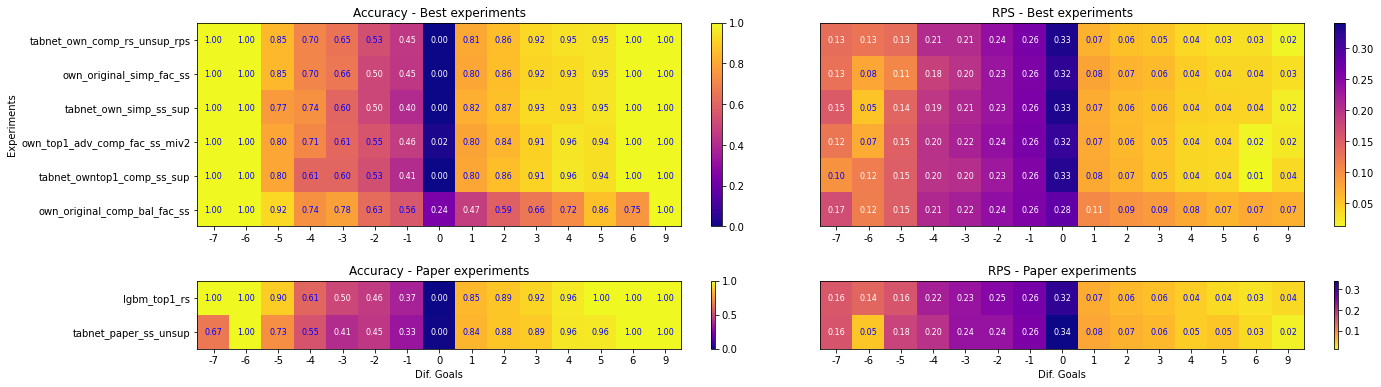

In [239]:
# DIF_RES

groupby = logits_topleagues.groupby('dif_res')
matrix_acc = groupby[[*map(lambda x: 'accurate_flag_'+x ,top_experiments)]].mean().T.dropna(axis=1)
matrix_rps = groupby[[*map(lambda x: 'rps_'+x ,top_experiments)]].mean().T.dropna(axis=1)
matrix_acc_paper = groupby[[*map(lambda x: 'accurate_flag_'+x ,paper_exp)]].mean().T.dropna(axis=1)
matrix_rps_paper = groupby[[*map(lambda x: 'rps_'+x ,paper_exp)]].mean().T.dropna(axis=1)

# Define color map
color_maps = ['viridis', 'plasma', 'inferno', 'magma', 'cividis']
cmap = color_maps[1]
rps_min, rps_max = pd.concat([matrix_rps_paper,matrix_rps]).values.min(), pd.concat([matrix_rps_paper,matrix_rps]).values.max()
print(rps_min,rps_max)
acc_min, acc_max = pd.concat([matrix_acc_paper,matrix_acc]).values.min(), pd.concat([matrix_acc_paper,matrix_acc]).values.max()

# Define fixed height for each row
row_height = 0.75  # Adjust this value as needed
# Calculate the height for each subplot based on the number of rows
heights = [len(matrix_acc), len(matrix_acc_paper)]  # Number of rows in each subplot
# Create the subplots with specified heights
fig, axes = plt.subplots(2, 2, figsize=(22, sum(heights) * row_height), 
                         gridspec_kw={'height_ratios': heights})
plt.subplots_adjust(hspace=0.4, wspace=0.03)

def add_numbers_to_heatmap(matrix, ax, color_func=lambda v: 'blue' if v>0.5 else 'white'):
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            text = ax.text(j, i, f'{matrix.iloc[i, j]:.2f}',
                           ha='center', va='center', color=color_func(matrix.iloc[i, j]), fontsize=8)

# Plot first heatmap
cax1 = axes[0][0].imshow(matrix_acc, cmap=cmap, aspect='auto',vmin=acc_min, vmax=acc_max)
add_numbers_to_heatmap(matrix_acc, axes[0][0])
ax[0].set_title('Accuracy - Best experiments')
axes[0][0].set_ylabel('Experiments')
axes[0][0].set_xticks(np.arange(len(matrix_acc.columns)))
axes[0][0].set_xticklabels(matrix_acc.columns, rotation=0)
axes[0][0].set_yticks(np.arange(len(matrix_acc)))
axes[0][0].set_yticklabels(map(lambda x: x.replace('accurate_flag_',''),matrix_acc.index))
fig.colorbar(cax1, ax=axes[0][0])

# Plot second heatmap
cax2 = axes[0][1].imshow(matrix_rps, cmap=cmap+'_r', aspect='auto',vmin=rps_min, vmax=rps_max)
add_numbers_to_heatmap(matrix_rps, axes[0][1],color_func=lambda v: 'blue' if v<0.1 else 'white')
axes[0][1].set_title('RPS - Best experiments')
axes[0][1].set_xticks(np.arange(len(matrix_rps.columns)))
axes[0][1].set_xticklabels(matrix_rps.columns, rotation=0)
axes[0][1].set_yticks([])
fig.colorbar(cax2, ax=axes[0][1])

# Plot first heatmap
cax3 = axes[1][0].imshow(matrix_acc_paper, cmap=cmap, aspect='auto',vmin=acc_min, vmax=acc_max)
add_numbers_to_heatmap(matrix_acc_paper, axes[1][0])
axes[1][0].set_title('Accuracy - Paper experiments')
axes[0][0].set_ylabel('Experiments')
axes[1][0].set_xlabel('Dif. Goals')
axes[1][0].set_xticks(np.arange(len(matrix_acc_paper.columns)))
axes[1][0].set_xticklabels(matrix_acc_paper.columns, rotation=0)
axes[1][0].set_yticks(np.arange(len(matrix_acc_paper)))
axes[1][0].set_yticklabels(map(lambda x: x.replace('accurate_flag_',''),matrix_acc_paper.index))
fig.colorbar(cax3, ax=axes[1][0])

# Plot second heatmap
cax4 = axes[1][1].imshow(matrix_rps_paper, cmap=cmap+'_r', aspect='auto', vmin=rps_min, vmax=rps_max)
add_numbers_to_heatmap(matrix_rps_paper, axes[1][1],color_func=lambda v: 'blue' if v<0.1 else 'white')
axes[1][1].set_title('RPS - Paper experiments')
axes[1][1].set_xlabel('Dif. Goals')
axes[1][1].set_xticks(np.arange(len(matrix_rps_paper.columns)))
axes[1][1].set_xticklabels(matrix_rps_paper.columns, rotation=0)
axes[1][1].set_yticks([])
fig.colorbar(cax4, ax=axes[1][1])

if save: plt.savefig(PATH_GRAPHS+'difgoals_acc_heatmap.jpeg', bbox_inches='tight', dpi='figure')
plt.show()

0.18147214844011142 0.20782359464556963


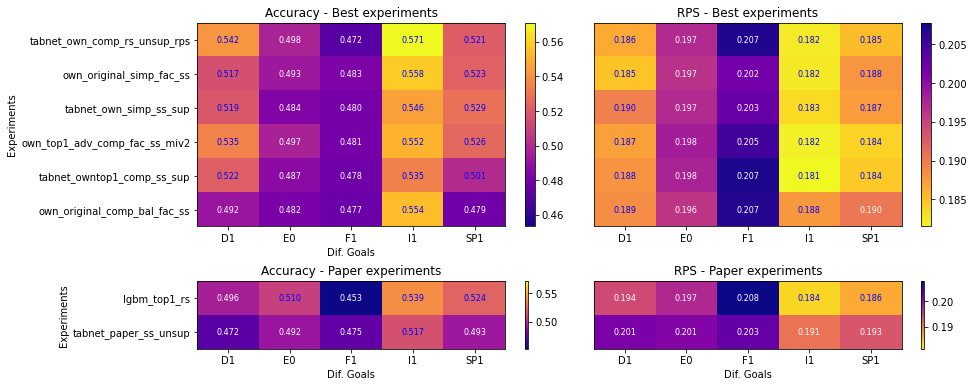

In [240]:
# DIV

groupby = logits_topleagues.groupby('Div')
matrix_acc = groupby[[*map(lambda x: 'accurate_flag_'+x ,top_experiments)]].mean().T.dropna(axis=1)
matrix_rps = groupby[[*map(lambda x: 'rps_'+x ,top_experiments)]].mean().T.dropna(axis=1)
matrix_acc_paper = groupby[[*map(lambda x: 'accurate_flag_'+x ,paper_exp)]].mean().T.dropna(axis=1)
matrix_rps_paper = groupby[[*map(lambda x: 'rps_'+x ,paper_exp)]].mean().T.dropna(axis=1)

# Define color map
color_maps = ['viridis', 'plasma', 'inferno', 'magma', 'cividis']
cmap = color_maps[1]
rps_min, rps_max = pd.concat([matrix_rps_paper,matrix_rps]).values.min(), pd.concat([matrix_rps_paper,matrix_rps]).values.max()
print(rps_min,rps_max)
acc_min, acc_max = pd.concat([matrix_acc_paper,matrix_acc]).values.min(), pd.concat([matrix_acc_paper,matrix_acc]).values.max()

# Define fixed height for each row
row_height = 0.75  # Adjust this value as needed
# Calculate the height for each subplot based on the number of rows
heights = [len(matrix_acc), len(matrix_acc_paper)]  # Number of rows in each subplot
# Create the subplots with specified heights
fig, axes = plt.subplots(2, 2, figsize=(14, sum(heights) * row_height), 
                         gridspec_kw={'height_ratios': heights})
plt.subplots_adjust(hspace=0.4, wspace=0.03)

def add_numbers_to_heatmap(matrix, ax, color_func=lambda v: 'blue' if v>0.5 else 'white'):
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            text = ax.text(j, i, f'{matrix.iloc[i, j]:.3f}',
                           ha='center', va='center', color=color_func(matrix.iloc[i, j]), fontsize=8)

# Plot first heatmap
cax1 = axes[0][0].imshow(matrix_acc, cmap=cmap, aspect='auto',vmin=acc_min, vmax=acc_max)
add_numbers_to_heatmap(matrix_acc, axes[0][0])
axes[0][0].set_title('Accuracy - Best experiments')
axes[0][0].set_xlabel('Dif. Goals')
axes[0][0].set_ylabel('Experiments')
axes[0][0].set_xticks(np.arange(len(matrix_acc.columns)))
axes[0][0].set_xticklabels(matrix_acc.columns, rotation=0)
axes[0][0].set_yticks(np.arange(len(matrix_acc)))
axes[0][0].set_yticklabels(map(lambda x: x.replace('accurate_flag_',''),matrix_acc.index))
fig.colorbar(cax1, ax=axes[0][0])

# Plot second heatmap
cax2 = axes[0][1].imshow(matrix_rps, cmap=cmap+'_r', aspect='auto',vmin=rps_min, vmax=rps_max)
add_numbers_to_heatmap(matrix_rps, axes[0][1],color_func=lambda v: 'blue' if v<0.19 else 'white')
axes[0][1].set_title('RPS - Best experiments')
axes[0][1].set_xticks(np.arange(len(matrix_rps.columns)))
axes[0][1].set_xticklabels(matrix_rps.columns, rotation=0)
axes[0][1].set_yticks([])
fig.colorbar(cax2, ax=axes[0][1])

# Plot first heatmap
cax3 = axes[1][0].imshow(matrix_acc_paper, cmap=cmap, aspect='auto',vmin=acc_min, vmax=acc_max)
add_numbers_to_heatmap(matrix_acc_paper, axes[1][0])
axes[1][0].set_title('Accuracy - Paper experiments')
axes[1][0].set_xlabel('Dif. Goals')
axes[1][0].set_ylabel('Experiments')
axes[1][0].set_xticks(np.arange(len(matrix_acc_paper.columns)))
axes[1][0].set_xticklabels(matrix_acc_paper.columns, rotation=0)
axes[1][0].set_yticks(np.arange(len(matrix_acc_paper)))
axes[1][0].set_yticklabels(map(lambda x: x.replace('accurate_flag_',''),matrix_acc_paper.index))
fig.colorbar(cax3, ax=axes[1][0])

# Plot second heatmap
cax4 = axes[1][1].imshow(matrix_rps_paper, cmap=cmap+'_r', aspect='auto', vmin=rps_min, vmax=rps_max)
add_numbers_to_heatmap(matrix_rps_paper, axes[1][1],color_func=lambda v: 'blue' if v<0.19 else 'white')
axes[1][1].set_title('RPS - Paper experiments')
axes[1][1].set_xlabel('Dif. Goals')
axes[1][1].set_xticks(np.arange(len(matrix_rps_paper.columns)))
axes[1][1].set_xticklabels(matrix_rps_paper.columns, rotation=0)
axes[1][1].set_yticks([])
fig.colorbar(cax4, ax=axes[1][1])

if save: plt.savefig(PATH_GRAPHS+'div_heatmap.jpeg', bbox_inches='tight', dpi='figure')
plt.show()

0.05904854807692308 0.34105121981651376


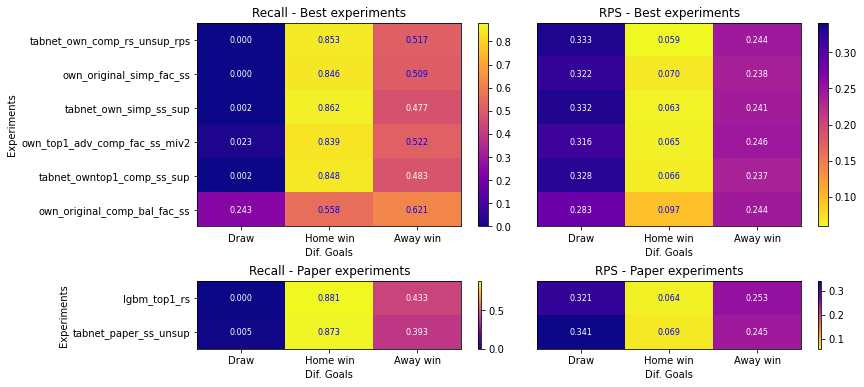

In [241]:
# RECALL (label)

groupby = logits_topleagues.groupby('label')
matrix_acc = groupby[[*map(lambda x: 'accurate_flag_'+x ,top_experiments)]].mean().T.dropna(axis=1)
matrix_rps = groupby[[*map(lambda x: 'rps_'+x ,top_experiments)]].mean().T.dropna(axis=1)
matrix_acc_paper = groupby[[*map(lambda x: 'accurate_flag_'+x ,paper_exp)]].mean().T.dropna(axis=1)
matrix_rps_paper = groupby[[*map(lambda x: 'rps_'+x ,paper_exp)]].mean().T.dropna(axis=1)

labels_dict = {0:'Draw',1:'Home win',2:'Away win'}

# Define color map
color_maps = ['viridis', 'plasma', 'inferno', 'magma', 'cividis']
cmap = color_maps[1]
rps_min, rps_max = pd.concat([matrix_rps_paper,matrix_rps]).values.min(), pd.concat([matrix_rps_paper,matrix_rps]).values.max()
print(rps_min,rps_max)
acc_min, acc_max = pd.concat([matrix_acc_paper,matrix_acc]).values.min(), pd.concat([matrix_acc_paper,matrix_acc]).values.max()

# Define fixed height for each row
row_height = 0.75  # Adjust this value as needed
# Calculate the height for each subplot based on the number of rows
heights = [len(matrix_acc), len(matrix_acc_paper)]  # Number of rows in each subplot
# Create the subplots with specified heights
fig, axes = plt.subplots(2, 2, figsize=(12, sum(heights) * row_height), 
                         gridspec_kw={'height_ratios': heights})
plt.subplots_adjust(hspace=0.4, wspace=0.03)
# fig.suptitle("RECALL",fontsize=20)

def add_numbers_to_heatmap(matrix, ax, color_func=lambda v: 'blue' if v>0.5 else 'white'):
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            text = ax.text(j, i, f'{matrix.iloc[i, j]:.3f}',
                           ha='center', va='center', color=color_func(matrix.iloc[i, j]), fontsize=8)

# Plot first heatmap
cax1 = axes[0][0].imshow(matrix_acc, cmap=cmap, aspect='auto',vmin=acc_min, vmax=acc_max)
add_numbers_to_heatmap(matrix_acc, axes[0][0])
axes[0][0].set_title('Recall - Best experiments')
axes[0][0].set_xlabel('Dif. Goals')
axes[0][0].set_ylabel('Experiments')
axes[0][0].set_xticks(np.arange(len(matrix_acc.columns)))
axes[0][0].set_xticklabels(matrix_acc.columns.map(labels_dict), rotation=0)
axes[0][0].set_yticks(np.arange(len(matrix_acc)))
axes[0][0].set_yticklabels(map(lambda x: x.replace('accurate_flag_',''),matrix_acc.index))
fig.colorbar(cax1, ax=axes[0][0])

# Plot second heatmap
cax2 = axes[0][1].imshow(matrix_rps, cmap=cmap+'_r', aspect='auto',vmin=rps_min, vmax=rps_max)
add_numbers_to_heatmap(matrix_rps, axes[0][1],color_func=lambda v: 'blue' if v<0.1 else 'white')
axes[0][1].set_title('RPS - Best experiments')
axes[0][1].set_xlabel('Dif. Goals')
axes[0][1].set_xticks(np.arange(len(matrix_rps.columns)))
axes[0][1].set_xticklabels(matrix_rps.columns.map(labels_dict), rotation=0)
axes[0][1].set_yticks([])
fig.colorbar(cax2, ax=axes[0][1])

# Plot first heatmap
cax3 = axes[1][0].imshow(matrix_acc_paper, cmap=cmap, aspect='auto',vmin=acc_min, vmax=acc_max)
add_numbers_to_heatmap(matrix_acc_paper, axes[1][0])
axes[1][0].set_title('Recall - Paper experiments')
axes[1][0].set_xlabel('Dif. Goals')
axes[1][0].set_ylabel('Experiments')
axes[1][0].set_xticks(np.arange(len(matrix_acc_paper.columns)))
axes[1][0].set_xticklabels(matrix_acc_paper.columns.map(labels_dict), rotation=0)
axes[1][0].set_yticks(np.arange(len(matrix_acc_paper)))
axes[1][0].set_yticklabels(map(lambda x: x.replace('accurate_flag_',''),matrix_acc_paper.index))
fig.colorbar(cax3, ax=axes[1][0])

# Plot second heatmap
cax4 = axes[1][1].imshow(matrix_rps_paper, cmap=cmap+'_r', aspect='auto', vmin=rps_min, vmax=rps_max)
add_numbers_to_heatmap(matrix_rps_paper, axes[1][1],color_func=lambda v: 'blue' if v<0.1 else 'white')
axes[1][1].set_title('RPS - Paper experiments')
axes[1][1].set_xlabel('Dif. Goals')
axes[1][1].set_xticks(np.arange(len(matrix_rps_paper.columns)))
axes[1][1].set_xticklabels(matrix_rps_paper.columns.map(labels_dict), rotation=0)
axes[1][1].set_yticks([])
fig.colorbar(cax4, ax=axes[1][1])

if save: plt.savefig(PATH_GRAPHS+'recall_acc_heatmap.jpeg', bbox_inches='tight', dpi='figure')
plt.show()

(6, 3) (2, 3)
0.3062645011600928 1.0


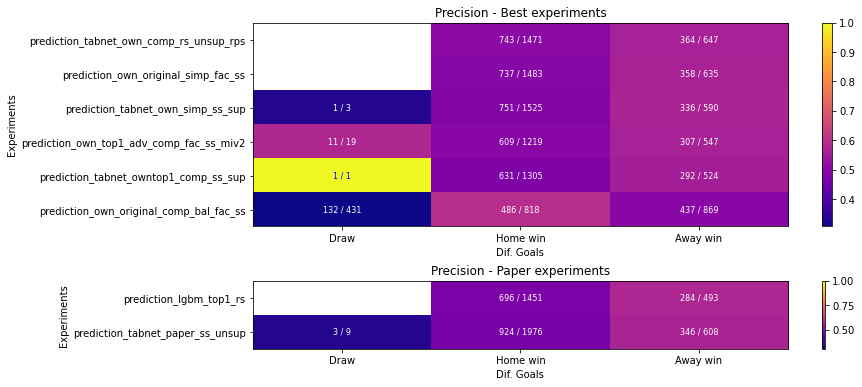

In [242]:
# PRECISION

groupby = (logits_topleagues.melt(id_vars=METADATA, value_vars=[col for col in logits_topleagues.columns if col.startswith('prediction')])
                            .assign(accurate=lambda x: x['value']==x['label'])
                            .groupby(['variable','value']))['accurate']
matrix_acc = groupby.mean().reset_index().pivot(index='value',columns='variable',values='accurate')[[*map(lambda x: 'prediction_'+x ,top_experiments)]].T
matrix_acc_paper = groupby.mean().reset_index().pivot(index='value',columns='variable',values='accurate')[[*map(lambda x: 'prediction_'+x ,paper_exp)]].T
matrix_sum = groupby.sum().reset_index().pivot(index='value',columns='variable',values='accurate')[[*map(lambda x: 'prediction_'+x ,top_experiments)]].T
matrix_sum_paper = groupby.sum().reset_index().pivot(index='value',columns='variable',values='accurate')[[*map(lambda x: 'prediction_'+x ,paper_exp)]].T
matrix_count = groupby.count().reset_index().pivot(index='value',columns='variable',values='accurate')[[*map(lambda x: 'prediction_'+x ,top_experiments)]].T
matrix_count_paper = groupby.count().reset_index().pivot(index='value',columns='variable',values='accurate')[[*map(lambda x: 'prediction_'+x ,paper_exp)]].T
print(matrix_acc.shape,matrix_acc_paper.shape)

labels_dict = {0:'Draw',1:'Home win',2:'Away win'}

# Define color map
color_maps = ['viridis', 'plasma', 'inferno', 'magma', 'cividis']
cmap = color_maps[1]
acc_min, acc_max = pd.concat([matrix_acc_paper,matrix_acc]).min(None), pd.concat([matrix_acc_paper,matrix_acc]).max(None)
print(acc_min,acc_max)

# Define fixed height for each row
row_height = 0.75  # Adjust this value as needed
# Calculate the height for each subplot based on the number of rows
heights = [len(matrix_acc), len(matrix_acc_paper)]  # Number of rows in each subplot
# Create the subplots with specified heights
fig, (ax1,ax2) = plt.subplots(2, 1, figsize=(12, sum(heights) * row_height), 
                         gridspec_kw={'height_ratios': heights})
# fig.suptitle("PRECISION",fontsize=20)
plt.subplots_adjust(hspace=0.4, wspace=0.03)

def add_numbers_to_heatmap(matrix,matrix_sum,matrix_count, ax, color_func=lambda v: 'blue' if v>0.6 else 'white'):
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            text = ax.text(j, i, f'{matrix_sum.iloc[i, j]:.0f} / {matrix_count.iloc[i, j]:.0f}',
                           ha='center', va='center', color=color_func(matrix.iloc[i, j]), fontsize=8)

# Plot first heatmap
cax1 = ax1.imshow(matrix_acc, cmap=cmap, aspect='auto',vmin=acc_min, vmax=acc_max)
add_numbers_to_heatmap(matrix_acc,matrix_sum,matrix_count, ax1)
ax1.set_title('Precision - Best experiments')
ax1.set_xlabel('Dif. Goals')
ax1.set_ylabel('Experiments')
ax1.set_xticks(np.arange(len(matrix_acc.columns)))
ax1.set_xticklabels(matrix_acc.columns.map(labels_dict), rotation=0)
ax1.set_yticks(np.arange(len(matrix_acc)))
ax1.set_yticklabels(map(lambda x: x.replace('accurate_flag_',''),matrix_acc.index))
fig.colorbar(cax1, ax=ax1)

# Plot first heatmap
cax3 = ax2.imshow(matrix_acc_paper, cmap=cmap, aspect='auto',vmin=acc_min, vmax=acc_max)
add_numbers_to_heatmap(matrix_acc_paper,matrix_sum_paper,matrix_count_paper, ax2)
ax2.set_title('Precision - Paper experiments')
ax2.set_xlabel('Dif. Goals')
ax2.set_ylabel('Experiments')
ax2.set_xticks(np.arange(len(matrix_acc_paper.columns)))
ax2.set_xticklabels(matrix_acc_paper.columns.map(labels_dict), rotation=0)
ax2.set_yticks(np.arange(len(matrix_acc_paper)))
ax2.set_yticklabels(map(lambda x: x.replace('accurate_flag_',''),matrix_acc_paper.index))
fig.colorbar(cax3, ax=ax2)

if save: plt.savefig(PATH_GRAPHS+'precision_heatmap.jpeg', bbox_inches='tight', dpi='figure')
plt.show()

#### por Aciertos

In [19]:
melt_acc = logits_topleagues.melt(id_vars=METADATA, value_vars=[col for col in logits_topleagues.columns if col.startswith('accurate')]).rename(columns={'value':'acc'})
melt_acc.loc[:,'variable'] = melt_acc.variable.apply(lambda c: '_'.join(c.split('_')[2:]))
melt_rps = logits_topleagues.melt(id_vars=METADATA, value_vars=[col for col in logits_topleagues.columns if col.startswith('rps')]).rename(columns={'value':'rps'})
melt_rps.loc[:,'variable'] = melt_rps.variable.apply(lambda c: '_'.join(c.split('_')[1:]))

melt_df = pd.merge(melt_acc,melt_rps,on=METADATA+['variable'],how='inner')
melt_df.loc[:,"dif_res"] = melt_df.FTHG - melt_df.FTAG
melt_ok = melt_df[melt_df.acc==1]
melt_bad = melt_df[melt_df.acc==0]
melt_ok

,match,Date,season,Div,HomeTeam,AwayTeam,FTHG,FTAG,label,variable,acc,rps,dif_res
1,15971,2020-01-01,T19-20,E0,Newcastle,Leicester,0,3,2.0,lgbm_top1_rs,1.0,0.218283,-3
3,15973,2020-01-01,T19-20,E0,Watford,Wolves,2,1,1.0,lgbm_top1_rs,1.0,0.100803,1
4,15974,2020-01-01,T19-20,E0,Man City,Everton,2,1,1.0,lgbm_top1_rs,1.0,0.018181,1
6,15976,2020-01-01,T19-20,E0,West Ham,Bournemouth,4,0,1.0,lgbm_top1_rs,1.0,0.079109,4
7,15977,2020-01-01,T19-20,E0,Arsenal,Man United,2,0,1.0,lgbm_top1_rs,1.0,0.094558,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20455,35630,2021-05-12,T20-21,I1,Inter,Roma,3,1,1.0,tabnet_own_comp_rs_unsup_rps,1.0,0.005593,2
20456,35631,2021-05-12,T20-21,I1,Lazio,Parma,1,0,1.0,tabnet_own_comp_rs_unsup_rps,1.0,0.009153,1
20458,35634,2021-05-12,T20-21,I1,Torino,Milan,0,7,2.0,tabnet_own_comp_rs_unsup_rps,1.0,0.163186,-7
20459,35633,2021-05-12,T20-21,I1,Sassuolo,Juventus,1,3,2.0,tabnet_own_comp_rs_unsup_rps,1.0,0.184096,-2


In [73]:
extra_cols = ['dif_res']

pivot_ok = melt_ok.pivot(index=METADATA+extra_cols,columns='variable',values='rps')
pivot_bad = melt_bad.pivot(index=METADATA+extra_cols,columns='variable',values='rps')
pivot_ok.mean().sort_values(), pivot_bad.mean().sort_values()

(variable
 own_original_simp_fac_ss         0.074351
 tabnet_paper_ss_unsup            0.074652
 tabnet_own_comp_rs_unsup_rps     0.075209
 tabnet_owntop1_comp_ss_sup       0.077898
 tabnet_own_simp_ss_sup           0.078728
 lgbm_top1_rs                     0.084642
 own_top1_adv_comp_fac_ss_miv2    0.084889
 own_original_comp_bal_fac_ss     0.142181
 dtype: float64,
 variable
 own_original_comp_bal_fac_ss     0.244314
 lgbm_top1_rs                     0.304978
 own_top1_adv_comp_fac_ss_miv2    0.304979
 tabnet_owntop1_comp_ss_sup       0.307269
 tabnet_own_simp_ss_sup           0.310578
 own_original_simp_fac_ss         0.314375
 tabnet_paper_ss_unsup            0.315720
 tabnet_own_comp_rs_unsup_rps     0.317561
 dtype: float64)

In [47]:
save = 1

In [31]:
groupby = pivot_ok.groupby('dif_res')
groupby[top_experiments].mean().T.dropna(axis=1)

pd.concat([matrix_ok,matrix_ok_paper,matrix_bad,matrix_bad_paper]).min(None)

0.0121890975

0.0121890975 0.3630151634057971


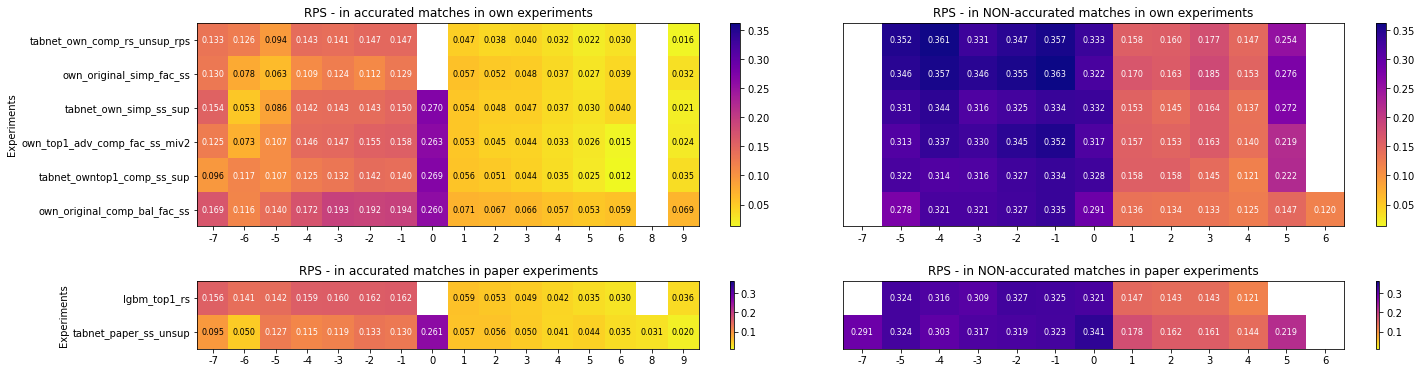

In [61]:
# DIF_RES
col_group = 'dif_res'
groupby = pivot_ok.groupby(col_group)
matrix_ok = groupby[top_experiments].mean().T#.dropna(axis=1)
matrix_ok_paper = groupby[paper_exp].mean().T#.dropna(axis=1)

groupby = pivot_bad.groupby(col_group)
matrix_bad = groupby[top_experiments].mean().T#.dropna(axis=1)
matrix_bad_paper = groupby[paper_exp].mean().T#.dropna(axis=1)

# Define color map
color_maps = ['viridis', 'plasma', 'inferno', 'magma', 'cividis']
cmap = color_maps[1]
rps_min, rps_max = pd.concat([matrix_ok,matrix_ok_paper,matrix_bad,matrix_bad_paper]).min(None), pd.concat([matrix_ok,matrix_ok_paper,matrix_bad,matrix_bad_paper]).max(None)
print(rps_min,rps_max)

# Define fixed height for each row
row_height = 0.75  # Adjust this value as needed
# Calculate the height for each subplot based on the number of rows
heights = [len(matrix_ok), len(matrix_ok_paper)]  # Number of rows in each subplot
# Create the subplots with specified heights
fig, axes = plt.subplots(2, 2, figsize=(10+len(matrix_ok.columns)*0.8, sum(heights) * row_height), 
                         gridspec_kw={'height_ratios': heights})
plt.subplots_adjust(hspace=0.4, wspace=0.03)

def add_numbers_to_heatmap(matrix, ax, color_func=lambda v: 'black' if v<0.1 else 'white'):
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            text = ax.text(j, i, f'{matrix.iloc[i, j]:.3f}',
                           ha='center', va='center', color=color_func(matrix.iloc[i, j]), fontsize=8)

# Plot first heatmap
df = matrix_ok
ax = axes[0][0]
cax1 = ax.imshow(df, cmap=cmap+'_r', aspect='auto',vmin=rps_min, vmax=rps_max)
add_numbers_to_heatmap(df, ax)
ax.set_title('RPS - in accurated matches in own experiments')
ax.set_ylabel('Experiments')
ax.set_xticks(np.arange(len(df.columns)))
ax.set_xticklabels(df.columns, rotation=0)
ax.set_yticks(np.arange(len(df)))
ax.set_yticklabels(map(lambda x: x.replace('accurate_flag_',''),df.index))
fig.colorbar(cax1, ax=ax)

df = matrix_bad
ax = axes[0][1]
cax1 = ax.imshow(df, cmap=cmap+'_r', aspect='auto',vmin=rps_min, vmax=rps_max)
add_numbers_to_heatmap(df, ax)
ax.set_title('RPS - in NON-accurated matches in own experiments')
ax.set_xticks(np.arange(len(df.columns)))
ax.set_xticklabels(df.columns, rotation=0)
ax.set_yticks([])
fig.colorbar(cax1, ax=ax)

df = matrix_ok_paper
ax = axes[1][0]
cax1 = ax.imshow(df, cmap=cmap+'_r', aspect='auto',vmin=rps_min, vmax=rps_max)
add_numbers_to_heatmap(df, ax)
ax.set_title('RPS - in accurated matches in paper experiments')
ax.set_ylabel('Experiments')
ax.set_xticks(np.arange(len(df.columns)))
ax.set_xticklabels(df.columns, rotation=0)
ax.set_yticks(np.arange(len(df)))
ax.set_yticklabels(map(lambda x: x.replace('accurate_flag_',''),df.index))
fig.colorbar(cax1, ax=ax)

df = matrix_bad_paper
ax = axes[1][1]
cax1 = ax.imshow(df, cmap=cmap+'_r', aspect='auto',vmin=rps_min, vmax=rps_max)
add_numbers_to_heatmap(df, ax)
ax.set_title('RPS - in NON-accurated matches in paper experiments')
ax.set_xticks(np.arange(len(df.columns)))
ax.set_xticklabels(df.columns, rotation=0)
ax.set_yticks([])
fig.colorbar(cax1, ax=ax)

if save: plt.savefig(PATH_GRAPHS+'difgoals_rps_matches_heatmap.jpeg', bbox_inches='tight', dpi='figure')
plt.show()

0.06553026236013987 0.15892707208333334
0.22928082731660232 0.3297434375


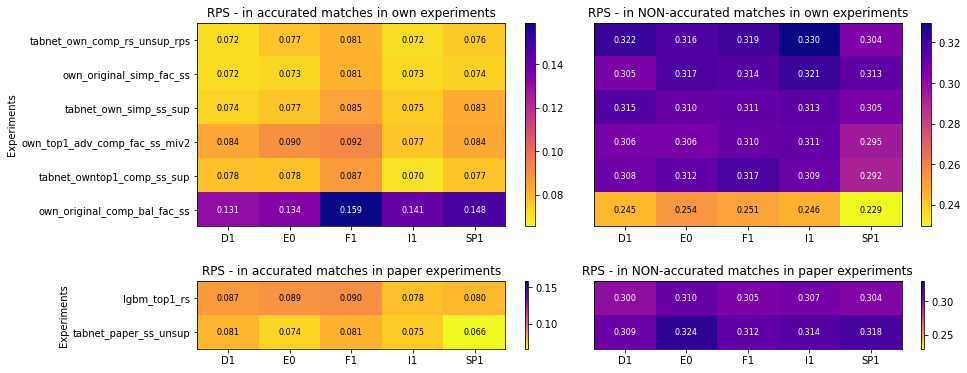

In [72]:
# DIV
col_group = 'Div'
groupby = pivot_ok.groupby(col_group)
matrix_ok = groupby[top_experiments].mean().T#.dropna(axis=1)
matrix_ok_paper = groupby[paper_exp].mean().T#.dropna(axis=1)

groupby = pivot_bad.groupby(col_group)
matrix_bad = groupby[top_experiments].mean().T#.dropna(axis=1)
matrix_bad_paper = groupby[paper_exp].mean().T#.dropna(axis=1)

# Define color map
color_maps = ['viridis', 'plasma', 'inferno', 'magma', 'cividis']
cmap = color_maps[1]

# Define fixed height for each row
row_height = 0.75  # Adjust this value as needed
# Calculate the height for each subplot based on the number of rows
heights = [len(matrix_ok), len(matrix_ok_paper)]  # Number of rows in each subplot
# Create the subplots with specified heights
fig, axes = plt.subplots(2, 2, figsize=(10+len(matrix_ok.columns)*0.8, sum(heights) * row_height), 
                         gridspec_kw={'height_ratios': heights})
plt.subplots_adjust(hspace=0.4, wspace=0.03)

def add_numbers_to_heatmap(matrix, ax, color_func=lambda v: 'black' if v<0.1 else 'white'):
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            text = ax.text(j, i, f'{matrix.iloc[i, j]:.3f}',
                           ha='center', va='center', color=color_func(matrix.iloc[i, j]), fontsize=8)

rps_min, rps_max = pd.concat([matrix_ok,matrix_ok_paper]).min(None), pd.concat([matrix_ok,matrix_ok_paper]).max(None)
print(rps_min,rps_max)

# Plot first heatmap
df = matrix_ok
ax = axes[0][0]
cax1 = ax.imshow(df, cmap=cmap+'_r', aspect='auto',vmin=rps_min, vmax=rps_max)
add_numbers_to_heatmap(df, ax)
ax.set_title('RPS - in accurated matches in own experiments')
ax.set_ylabel('Experiments')
ax.set_xticks(np.arange(len(df.columns)))
ax.set_xticklabels(df.columns, rotation=0)
ax.set_yticks(np.arange(len(df)))
ax.set_yticklabels(map(lambda x: x.replace('accurate_flag_',''),df.index))
fig.colorbar(cax1, ax=ax)

df = matrix_ok_paper
ax = axes[1][0]
cax1 = ax.imshow(df, cmap=cmap+'_r', aspect='auto',vmin=rps_min, vmax=rps_max)
add_numbers_to_heatmap(df, ax)
ax.set_title('RPS - in accurated matches in paper experiments')
ax.set_ylabel('Experiments')
ax.set_xticks(np.arange(len(df.columns)))
ax.set_xticklabels(df.columns, rotation=0)
ax.set_yticks(np.arange(len(df)))
ax.set_yticklabels(map(lambda x: x.replace('accurate_flag_',''),df.index))
fig.colorbar(cax1, ax=ax)

rps_min, rps_max = pd.concat([matrix_bad,matrix_bad_paper]).min(None), pd.concat([matrix_bad,matrix_bad_paper]).max(None)
print(rps_min,rps_max)

df = matrix_bad
ax = axes[0][1]
cax1 = ax.imshow(df, cmap=cmap+'_r', aspect='auto',vmin=rps_min, vmax=rps_max)
add_numbers_to_heatmap(df, ax, color_func=lambda v: 'black' if v<0.275 else 'white')
ax.set_title('RPS - in NON-accurated matches in own experiments')
ax.set_xticks(np.arange(len(df.columns)))
ax.set_xticklabels(df.columns, rotation=0)
ax.set_yticks([])
fig.colorbar(cax1, ax=ax)

df = matrix_bad_paper
ax = axes[1][1]
cax1 = ax.imshow(df, cmap=cmap+'_r', aspect='auto',vmin=rps_min, vmax=rps_max)
add_numbers_to_heatmap(df, ax, color_func=lambda v: 'black' if v<0.275 else 'white')
ax.set_title('RPS - in NON-accurated matches in paper experiments')
ax.set_xticks(np.arange(len(df.columns)))
ax.set_xticklabels(df.columns, rotation=0)
ax.set_yticks([])
fig.colorbar(cax1, ax=ax)

if save: plt.savefig(PATH_GRAPHS+'div_rps_accmatches_heatmap.jpeg', bbox_inches='tight', dpi='figure')
plt.show()

### FEATURES ANALYSIS

Ver como nuestros features tienen un impacto favorable en la mejora del modelo.
-   A nivel modelo (feat_importance)
-   A nivel partido (feat importance por partido)
-   TODO: training feature-wise

Demostrar mejoras en:
-   Resultados generales
-   En prediccion empates
-   ... (pensar)

In [18]:
save = 0

In [19]:
from pytorch_tabnet.tab_model import TabNetClassifier
import lightgbm as lgb

PATH_MODELS = 'F:\\TFG\\code\\framework\\logs\\models\\'

In [20]:
def ls_sorted(search_dir:str, filt=os.path.isdir):
    os.chdir(search_dir)
    files = filter(filt, os.listdir(search_dir))
    files = [os.path.join(search_dir, f) for f in files] # add path to each file
    files.sort(key=lambda x: os.path.getmtime(x),reverse=True)
    return files

In [21]:
top_experiments

['tabnet_own_comp_rs_unsup_rps',
 'own_original_simp_fac_ss',
 'tabnet_own_simp_ss_sup',
 'own_top1_adv_comp_fac_ss_miv2',
 'tabnet_owntop1_comp_ss_sup',
 'own_original_comp_bal_fac_ss']

In [22]:
ls_feat_imp = ls_sorted(PATH_MODELS)

In [23]:
feats_paths = []
for exp in top_experiments+paper_exp:
    list_paths = [ path for path in ls_feat_imp if re.match(rf'.+{exp}_\d+',path)]
    if len(list_paths)>0:
        feats_paths.append(list_paths[0])
    else:
        print(exp)

feats_paths

['F:\\TFG\\code\\framework\\logs\\models\\tabnet_own_comp_rs_unsup_rps_202406271926',
 'F:\\TFG\\code\\framework\\logs\\models\\own_original_simp_fac_ss_202405201113',
 'F:\\TFG\\code\\framework\\logs\\models\\tabnet_own_simp_ss_sup_202405260830',
 'F:\\TFG\\code\\framework\\logs\\models\\own_top1_adv_comp_fac_ss_miv2_202405121831',
 'F:\\TFG\\code\\framework\\logs\\models\\tabnet_owntop1_comp_ss_sup_202406150937',
 'F:\\TFG\\code\\framework\\logs\\models\\own_original_comp_bal_fac_ss_202405282103',
 'F:\\TFG\\code\\framework\\logs\\models\\lgbm_top1_rs_202405261535',
 'F:\\TFG\\code\\framework\\logs\\models\\tabnet_paper_ss_unsup_202406172147']

#### per MODEL

In [24]:
names_feats = [ path.split('\\')[-1] for path in feats_paths ]

dict_feats = {}
for name,path in zip(names_feats,feats_paths):
    try:
        df_feats = pd.read_csv(f'{path}\\feature_importance_{name}.csv',sep=';',decimal=',')
        df_feats = df_feats.rename(columns={'importance':name})
        df_feats.set_index('features',inplace=True)
        dict_feats[name] = df_feats
    except:
        print("No hay fichero para", name, " en el path: ", path)
        if name.startswith('lgbm'):
            file = ls_sorted(path,os.path.isfile)[0]
            lgbm_model = lgb.Booster(model_file=file)
            lgbm_importance = pd.DataFrame(data=lgbm_model.feature_importance(),index=lgbm_model.feature_name(),columns=[name])
            lgbm_importance.loc[:,name] = lgbm_importance / lgbm_importance.sum()
            lgbm_importance = lgbm_importance.sort_values(name,ascending=False)
            dict_feats[name] = lgbm_importance
            print("Feat-importance de LightGBM importadas: ", name)

len(dict_feats)

No hay fichero para own_original_simp_fac_ss_202405201113  en el path:  F:\TFG\code\framework\logs\models\own_original_simp_fac_ss_202405201113
No hay fichero para own_top1_adv_comp_fac_ss_miv2_202405121831  en el path:  F:\TFG\code\framework\logs\models\own_top1_adv_comp_fac_ss_miv2_202405121831
No hay fichero para own_original_comp_bal_fac_ss_202405282103  en el path:  F:\TFG\code\framework\logs\models\own_original_comp_bal_fac_ss_202405282103
No hay fichero para lgbm_top1_rs_202405261535  en el path:  F:\TFG\code\framework\logs\models\lgbm_top1_rs_202405261535
Feat-importance de LightGBM importadas:  lgbm_top1_rs_202405261535


5

In [25]:
df_concat = pd.concat(dict_feats.values(),axis=1,join='outer').round(5).sort_index()
df_concat.columns = ['_'.join(col.split('_')[:-1]) for col in df_concat.columns]
df_concat = df_concat*100

In [26]:
df_concat#.sort_index()

,tabnet_own_comp_rs_unsup_rps,tabnet_own_simp_ss_sup,tabnet_owntop1_comp_ss_sup,lgbm_top1_rs,tabnet_paper_ss_unsup
C_15D_A,0.0,NaN,0.000,NaN,NaN
C_15D_H,0.0,NaN,0.000,NaN,NaN
C_180D_A,0.0,NaN,1.164,NaN,NaN
C_180D_H,0.0,NaN,3.429,NaN,NaN
C_1825D_A,0.0,NaN,0.000,NaN,NaN
...,...,...,...,...,...
top3_H,NaN,NaN,0.263,1.703,NaN
top4_A,NaN,NaN,0.000,1.703,NaN
top4_H,NaN,NaN,0.341,2.347,NaN
top5_A,NaN,NaN,0.073,1.519,NaN


In [27]:
def transform_string(s):
    if s.startswith('FTG_rival'):
        return '_'.join(s.split('_')[:2]).lower()
    elif s.startswith('st') or s.startswith('lt'):
        if 'FTG_rival' in s:
            return '_'.join(s.split('_')[1:3]).lower()
        s = s.split('_')[1]
    elif not s.startswith('rate'):
        s = s.split('_')[0]
        s = re.sub(r'top\d+', 'top', s)
        s = re.sub(r'down\d+', 'down', s)
    return s.lower()

is_short = lambda s: reduce(lambda x,y: x or y,[ val in s for val in ['15','30','60'] ])
is_long  = lambda s: reduce(lambda x,y: x or y,[ val in s for val in ['180','365','730','1825'] ])

def get_lag(s):
    if is_short(s) or s.startswith('st'): return 'shortterm'
    if is_long(s) or s.startswith('lt'): return 'longterm'
    return s

In [28]:
dict_types = {
    1: {
        'c':'events',
        'f':'events',
        'r':'events',
        'y':'events',
        'st':'events',
        's':'events',
        'ftg_rival': 'goals',
        'ftg': 'goals',
        'down': 'match_importance',
        'top': 'match_importance',
        'rounds':'match_importance',
        'draw':'points',
        'win':'points',
        'rate_away':'piratings',
        'rate_home':'piratings',
    },
    2: {
        'c':'lags',
        'f':'lags',
        'r':'lags',
        'y':'lags',
        'st':'lags',
        's':'lags',
        'ftg_rival': 'lags',
        'ftg': 'lags',
        'down': 'match_importance',
        'top': 'match_importance',
        'rounds':'match_importance',
        'draw':'lags',
        'win':'lags',
        'rate_away':'piratings',
        'rate_home':'piratings',
        'points':'lags',
        'side':'lags'
    },

}

In [280]:
# df_concat.loc[:,'type_feat'] = df_concat.index.map(get_lag)
# df_concat.loc[:,'type_feat'] = df_concat.type_feat.apply(transform_string)

df_concat.loc[:,'type_feat'] = df_concat.index.map(transform_string)

df_concat.loc[:,'type_feat'] = df_concat.type_feat.apply(lambda x: dict_types[2].get(x,x))

In [281]:
df_agg_feats = df_concat.groupby('type_feat').sum().reset_index()
df_agg_feats

,type_feat,tabnet_own_comp_rs_unsup_rps,tabnet_own_simp_ss_sup,tabnet_owntop1_comp_ss_sup,lgbm_top1_rs,tabnet_paper_ss_unsup
0,lags,99.998,99.999,80.651,40.817,0.0
1,match_importance,0.000,0.000,13.546,40.178,0.0
2,pagerank,0.000,0.000,2.781,7.409,0.0
3,piratings,0.000,0.000,3.018,11.597,100.0


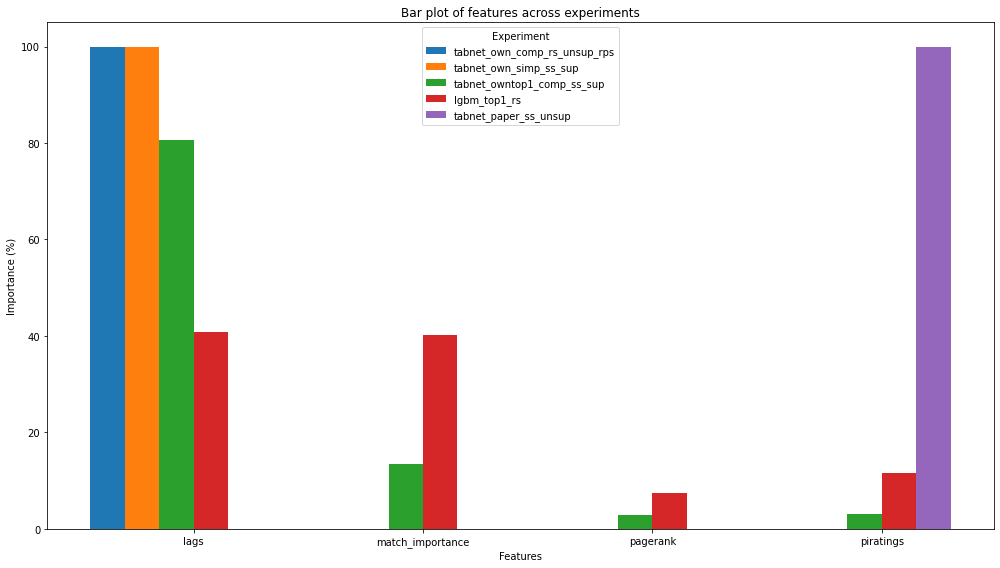

In [282]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Reshape the dataframe to long format
df_melted = df_agg_feats.melt(id_vars='type_feat', var_name='experiment', value_name='value')

# Define the order of the features
features_order = df_agg_feats['type_feat'].unique()

# Create the bar plot
plt.figure(figsize=(14, 8))
ax = plt.gca()

# Define the width of each bar and the positions
bar_width = 0.15
n_features = len(features_order)
n_experiments = df_melted['experiment'].nunique()

# Define the positions for the bars
positions = np.arange(n_features)
offsets = (np.arange(n_experiments) - n_experiments / 2) * bar_width

# Plot each experiment as a bar for each feature
for i, (experiment, offset) in enumerate(zip(df_melted['experiment'].unique(), offsets)):
    subset = df_melted[df_melted['experiment'] == experiment]
    bar_positions = positions + offset
    ax.bar(bar_positions, subset['value'], width=bar_width, label=experiment)

# Customize the plot
plt.xlabel('Features')
plt.ylabel('Importance (%)')
plt.title('Bar plot of features across experiments')
plt.xticks(positions, features_order, rotation=0)
plt.legend(title='Experiment')
plt.tight_layout()

# Save the figure
if save: plt.savefig(PATH_GRAPHS+'feat_imp_compare_agg.jpeg', bbox_inches='tight', dpi='figure', format='jpeg')

# Show the plot
plt.show()


#### per MATCH

### LOGITS ANALYSIS

-   Experiments with more variation (varianza) in the prediction 
-   Distribution of logits in accurate and non-accurate matches
    -   Per Div, Dif-goals, Label

In [20]:
melt_draw = logits_topleagues.melt(id_vars=METADATA, value_vars=[col for col in logits_topleagues.columns if col.startswith('draw')]).rename(columns={'value':'logit'})
melt_home = logits_topleagues.melt(id_vars=METADATA, value_vars=[col for col in logits_topleagues.columns if col.startswith('home')]).rename(columns={'value':'logit'})
melt_away = logits_topleagues.melt(id_vars=METADATA, value_vars=[col for col in logits_topleagues.columns if col.startswith('away')]).rename(columns={'value':'logit'})

In [21]:
melt_concat = pd.concat([melt_draw,melt_home,melt_away])
melt_concat.loc[:,'class'] = melt_concat.variable.apply(lambda x: {'draw':0,'home':1,'away':2}[x.split('_')[0]])
melt_concat.loc[:,'variable'] = melt_concat.variable.apply(lambda c: '_'.join(c.split('_')[1:]))
melt_concat

,match,Date,season,Div,HomeTeam,AwayTeam,FTHG,FTAG,label,variable,logit,class
0,15969,2020-01-01,T19-20,E0,Brighton,Chelsea,1,1,0.0,lgbm_top1_rs,0.2546,0
1,15971,2020-01-01,T19-20,E0,Newcastle,Leicester,0,3,2.0,lgbm_top1_rs,0.2754,0
2,15972,2020-01-01,T19-20,E0,Southampton,Tottenham,1,0,1.0,lgbm_top1_rs,0.2548,0
3,15973,2020-01-01,T19-20,E0,Watford,Wolves,2,1,1.0,lgbm_top1_rs,0.2771,0
4,15974,2020-01-01,T19-20,E0,Man City,Everton,2,1,1.0,lgbm_top1_rs,0.1597,0
...,...,...,...,...,...,...,...,...,...,...,...,...
20739,6202,2020-12-05,T20-21,D1,Bielefeld,Mainz,2,1,1.0,tabnet_own_comp_rs_unsup_rps,NaN,2
20740,35366,2020-12-05,T20-21,I1,Spezia,Lazio,1,2,2.0,tabnet_own_comp_rs_unsup_rps,NaN,2
20741,45487,2020-12-06,T20-21,SP1,Villarreal,Elche,0,0,0.0,tabnet_own_comp_rs_unsup_rps,NaN,2
20742,35372,2020-12-06,T20-21,I1,Crotone,Napoli,0,4,2.0,tabnet_own_comp_rs_unsup_rps,NaN,2


##### Logits segun el Label

In [67]:
melt_class = melt_concat[melt_concat['class']==melt_concat['label']].dropna()
melt_class

,match,Date,season,Div,HomeTeam,AwayTeam,FTHG,FTAG,label,variable,logit,class
0,15969,2020-01-01,T19-20,E0,Brighton,Chelsea,1,1,0.0,lgbm_top1_rs,0.2546,0
5,15975,2020-01-01,T19-20,E0,Norwich,Crystal Palace,1,1,0.0,lgbm_top1_rs,0.2748,0
10,45178,2020-01-03,T19-20,SP1,Sevilla,Ath Bilbao,1,1,0.0,lgbm_top1_rs,0.2525,0
11,45177,2020-01-03,T19-20,SP1,Valladolid,Leganes,2,2,0.0,lgbm_top1_rs,0.2770,0
14,45182,2020-01-04,T19-20,SP1,Espanol,Barcelona,2,2,0.0,lgbm_top1_rs,0.2048,0
...,...,...,...,...,...,...,...,...,...,...,...,...
20454,16497,2021-05-11,T20-21,E0,Man United,Leicester,1,2,2.0,tabnet_own_comp_rs_unsup_rps,0.0761,2
20457,35629,2021-05-12,T20-21,I1,Bologna,Genoa,0,2,2.0,tabnet_own_comp_rs_unsup_rps,0.1728,2
20458,35634,2021-05-12,T20-21,I1,Torino,Milan,0,7,2.0,tabnet_own_comp_rs_unsup_rps,0.4911,2
20459,35633,2021-05-12,T20-21,I1,Sassuolo,Juventus,1,3,2.0,tabnet_own_comp_rs_unsup_rps,0.4588,2


In [68]:
pivot_class = melt_class.pivot(index=METADATA,columns='variable',values='logit').reset_index()
pivot_class

variable,match,Date,season,Div,HomeTeam,AwayTeam,FTHG,FTAG,label,lgbm_top1_rs,own_original_comp_bal_fac_ss,own_original_simp_fac_ss,own_top1_adv_comp_fac_ss_miv2,tabnet_own_comp_rs_unsup_rps,tabnet_own_simp_ss_sup,tabnet_owntop1_comp_ss_sup,tabnet_paper_ss_unsup
0,5967,2020-01-17,T19-20,D1,Schalke 04,M'gladbach,2,0,1.0,0.4518,NaN,NaN,NaN,NaN,NaN,NaN,0.6860
1,5968,2020-01-18,T19-20,D1,Augsburg,Dortmund,3,5,2.0,0.4367,NaN,NaN,NaN,NaN,NaN,NaN,0.5734
2,5969,2020-01-18,T19-20,D1,FC Koln,Wolfsburg,3,1,1.0,0.3660,NaN,NaN,NaN,NaN,NaN,NaN,0.3863
3,5970,2020-01-18,T19-20,D1,Fortuna Dusseldorf,Werder Bremen,0,1,2.0,0.3284,NaN,NaN,NaN,NaN,NaN,NaN,0.3998
4,5971,2020-01-18,T19-20,D1,Hoffenheim,Ein Frankfurt,1,2,2.0,0.1637,NaN,NaN,NaN,NaN,NaN,NaN,0.2182
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2588,45752,2021-05-22,T20-21,SP1,Osasuna,Sociedad,0,1,2.0,0.3559,0.4122,0.3993,0.4078,0.3508,0.3665,0.3621,0.3376
2589,45753,2021-05-22,T20-21,SP1,Real Madrid,Villarreal,2,1,1.0,0.5809,0.5089,0.6807,0.7532,0.8361,0.5903,0.5933,0.7168
2590,45754,2021-05-22,T20-21,SP1,Valladolid,Ath Madrid,1,2,2.0,0.5845,0.5496,0.7855,0.6350,0.5631,0.6206,0.6859,0.5543
2591,45755,2021-05-23,T20-21,SP1,Granada,Getafe,0,0,0.0,0.2875,0.3582,0.3389,0.3054,0.3092,0.2732,0.2955,0.2597


In [69]:
top_experiments+paper_exp

['tabnet_own_comp_rs_unsup_rps',
 'own_original_simp_fac_ss',
 'tabnet_own_simp_ss_sup',
 'own_top1_adv_comp_fac_ss_miv2',
 'tabnet_owntop1_comp_ss_sup',
 'own_original_comp_bal_fac_ss',
 'lgbm_top1_rs',
 'tabnet_paper_ss_unsup']

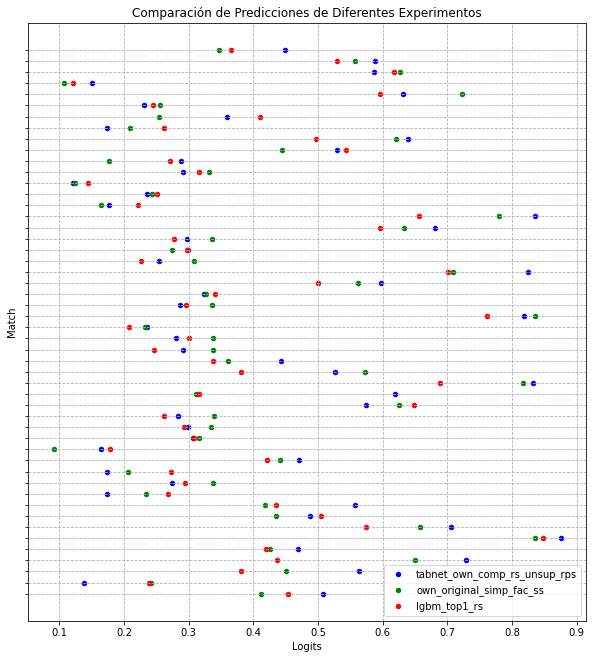

In [66]:
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'orange']

df = pivot_class.dropna().sample(50,random_state=0).reset_index(drop=True)

plt.figure(figsize=(10, 11))

for i, experiment in enumerate(['tabnet_own_comp_rs_unsup_rps','own_original_simp_fac_ss','lgbm_top1_rs']):
    plt.scatter(df[experiment], df.index, color=colors[i], label=experiment, s=20)
    
plt.ylabel('Match')
plt.xlabel('Logits')
plt.title('Comparación de Predicciones de Diferentes Experimentos')
plt.legend()
plt.yticks(ticks=df.index,labels=[], rotation=90)
plt.grid(axis='x',linestyle='--')
plt.grid(axis='y',linestyle='--')
plt.show()


In [70]:
pivot_class

variable,match,Date,season,Div,HomeTeam,AwayTeam,FTHG,FTAG,label,lgbm_top1_rs,own_original_comp_bal_fac_ss,own_original_simp_fac_ss,own_top1_adv_comp_fac_ss_miv2,tabnet_own_comp_rs_unsup_rps,tabnet_own_simp_ss_sup,tabnet_owntop1_comp_ss_sup,tabnet_paper_ss_unsup
0,5967,2020-01-17,T19-20,D1,Schalke 04,M'gladbach,2,0,1.0,0.4518,NaN,NaN,NaN,NaN,NaN,NaN,0.6860
1,5968,2020-01-18,T19-20,D1,Augsburg,Dortmund,3,5,2.0,0.4367,NaN,NaN,NaN,NaN,NaN,NaN,0.5734
2,5969,2020-01-18,T19-20,D1,FC Koln,Wolfsburg,3,1,1.0,0.3660,NaN,NaN,NaN,NaN,NaN,NaN,0.3863
3,5970,2020-01-18,T19-20,D1,Fortuna Dusseldorf,Werder Bremen,0,1,2.0,0.3284,NaN,NaN,NaN,NaN,NaN,NaN,0.3998
4,5971,2020-01-18,T19-20,D1,Hoffenheim,Ein Frankfurt,1,2,2.0,0.1637,NaN,NaN,NaN,NaN,NaN,NaN,0.2182
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2588,45752,2021-05-22,T20-21,SP1,Osasuna,Sociedad,0,1,2.0,0.3559,0.4122,0.3993,0.4078,0.3508,0.3665,0.3621,0.3376
2589,45753,2021-05-22,T20-21,SP1,Real Madrid,Villarreal,2,1,1.0,0.5809,0.5089,0.6807,0.7532,0.8361,0.5903,0.5933,0.7168
2590,45754,2021-05-22,T20-21,SP1,Valladolid,Ath Madrid,1,2,2.0,0.5845,0.5496,0.7855,0.6350,0.5631,0.6206,0.6859,0.5543
2591,45755,2021-05-23,T20-21,SP1,Granada,Getafe,0,0,0.0,0.2875,0.3582,0.3389,0.3054,0.3092,0.2732,0.2955,0.2597


In [71]:
pivot_class.loc[:,'dif_goals'] = pivot_class.FTHG - pivot_class.FTAG

In [72]:
pivot_class.groupby('dif_goals')[top_experiments].mean().T

dif_goals,-7,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6,8,9
variable,,,,,,,,,,,,,,,,
tabnet_own_comp_rs_unsup_rps,0.551633,0.5601,0.562908,0.440674,0.435630,0.382859,0.349437,0.251616,0.537095,0.591283,0.607616,0.667698,0.718277,0.720825,NaN,0.7625
own_original_simp_fac_ss,0.564933,0.6480,0.640492,0.497178,0.462548,0.408486,0.368698,0.275934,0.495831,0.541086,0.574339,0.639145,0.695523,0.656925,NaN,0.6634
tabnet_own_simp_ss_sup,0.510933,0.7092,0.555215,0.461163,0.422013,0.384666,0.345305,0.253055,0.512686,0.551955,0.577943,0.634903,0.690736,0.627450,NaN,0.7144
own_top1_adv_comp_fac_ss_miv2,0.576200,0.6689,0.545330,0.458867,0.426139,0.388352,0.354685,0.274961,0.504324,0.554241,0.587146,0.662018,0.685961,0.764300,NaN,0.7035
tabnet_owntop1_comp_ss_sup,0.616650,0.5877,0.542330,0.452022,0.445363,0.400233,0.360910,0.261648,0.500614,0.538416,0.589384,0.661639,0.698906,0.837350,NaN,0.6547
own_original_comp_bal_fac_ss,0.508167,0.6012,0.546785,0.450556,0.430777,0.399901,0.377475,0.334648,0.375855,0.411947,0.436949,0.481964,0.531291,0.486175,NaN,0.4933


In [73]:
melt_class[melt_class.match==15973].sort_values(['variable','class'])

,match,Date,season,Div,HomeTeam,AwayTeam,FTHG,FTAG,label,variable,logit,class
3,15973,2020-01-01,T19-20,E0,Watford,Wolves,2,1,1.0,lgbm_top1_rs,0.3696,1
2596,15973,2020-01-01,T19-20,E0,Watford,Wolves,2,1,1.0,own_original_comp_bal_fac_ss,0.2298,1
5189,15973,2020-01-01,T19-20,E0,Watford,Wolves,2,1,1.0,own_original_simp_fac_ss,0.2848,1
7782,15973,2020-01-01,T19-20,E0,Watford,Wolves,2,1,1.0,own_top1_adv_comp_fac_ss_miv2,0.2522,1
18154,15973,2020-01-01,T19-20,E0,Watford,Wolves,2,1,1.0,tabnet_own_comp_rs_unsup_rps,0.2938,1
12968,15973,2020-01-01,T19-20,E0,Watford,Wolves,2,1,1.0,tabnet_own_simp_ss_sup,0.3657,1
10375,15973,2020-01-01,T19-20,E0,Watford,Wolves,2,1,1.0,tabnet_owntop1_comp_ss_sup,0.2839,1
15561,15973,2020-01-01,T19-20,E0,Watford,Wolves,2,1,1.0,tabnet_paper_ss_unsup,0.3929,1


0.0072124891681027755 0.24027808301941977


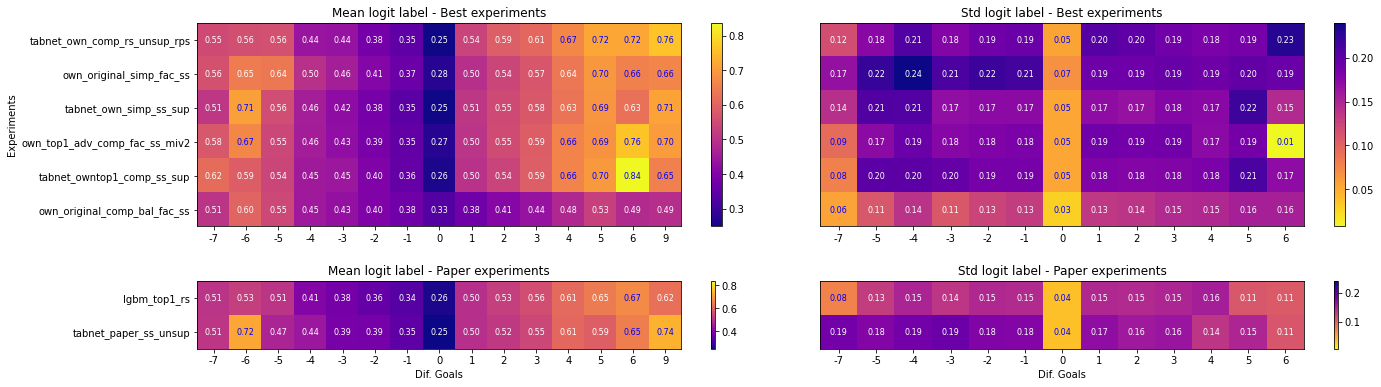

In [74]:
# DIF_RES

groupby = pivot_class.groupby('dif_goals')
matrix_mean = groupby[top_experiments].mean().dropna().T
matrix_std = groupby[top_experiments].std().dropna().T
matrix_mean_paper = groupby[paper_exp].mean().dropna().T
matrix_std_paper = groupby[paper_exp].std().dropna().T

# Define color map
color_maps = ['viridis', 'plasma', 'inferno', 'magma', 'cividis']
cmap = color_maps[1]
rps_min, rps_max = pd.concat([matrix_std,matrix_std_paper]).min(None), pd.concat([matrix_std,matrix_std_paper]).max(None)
print(rps_min,rps_max)
acc_min, acc_max = pd.concat([matrix_mean,matrix_mean_paper]).min(None), pd.concat([matrix_mean,matrix_mean_paper]).max(None)

# Define fixed height for each row
row_height = 0.75  # Adjust this value as needed
# Calculate the height for each subplot based on the number of rows
heights = [len(matrix_std), len(matrix_mean_paper)]  # Number of rows in each subplot
# Create the subplots with specified heights
fig, axes = plt.subplots(2, 2, figsize=(22, sum(heights) * row_height), 
                         gridspec_kw={'height_ratios': heights})
plt.subplots_adjust(hspace=0.4, wspace=0.03)

def add_numbers_to_heatmap(matrix, ax, color_func=lambda v: 'blue' if v>0.65 else 'white'):
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            text = ax.text(j, i, f'{matrix.iloc[i, j]:.2f}',
                           ha='center', va='center', color=color_func(matrix.iloc[i, j]), fontsize=8)

# Plot first heatmap
cax1 = axes[0][0].imshow(matrix_mean, cmap=cmap, aspect='auto',vmin=acc_min, vmax=acc_max)
add_numbers_to_heatmap(matrix_mean, axes[0][0])
axes[0][0].set_title('Mean logit label - Best experiments')
axes[0][0].set_ylabel('Experiments')
axes[0][0].set_xticks(np.arange(len(matrix_mean.columns)))
axes[0][0].set_xticklabels(matrix_mean.columns, rotation=0)
axes[0][0].set_yticks(np.arange(len(matrix_mean)))
axes[0][0].set_yticklabels(map(lambda x: x.replace('accurate_flag_',''),matrix_mean.index))
fig.colorbar(cax1, ax=axes[0][0])

# Plot second heatmap
cax2 = axes[0][1].imshow(matrix_std, cmap=cmap+'_r', aspect='auto',vmin=rps_min, vmax=rps_max)
add_numbers_to_heatmap(matrix_std, axes[0][1],color_func=lambda v: 'blue' if v<0.1 else 'white')
axes[0][1].set_title('Std logit label - Best experiments')
axes[0][1].set_xticks(np.arange(len(matrix_std.columns)))
axes[0][1].set_xticklabels(matrix_std.columns, rotation=0)
axes[0][1].set_yticks([])
fig.colorbar(cax2, ax=axes[0][1])

# Plot first heatmap
cax3 = axes[1][0].imshow(matrix_mean_paper, cmap=cmap, aspect='auto',vmin=acc_min, vmax=acc_max)
add_numbers_to_heatmap(matrix_mean_paper, axes[1][0])
axes[1][0].set_title('Mean logit label - Paper experiments')
axes[0][0].set_ylabel('Experiments')
axes[1][0].set_xlabel('Dif. Goals')
axes[1][0].set_xticks(np.arange(len(matrix_mean_paper.columns)))
axes[1][0].set_xticklabels(matrix_mean_paper.columns, rotation=0)
axes[1][0].set_yticks(np.arange(len(matrix_mean_paper)))
axes[1][0].set_yticklabels(map(lambda x: x.replace('accurate_flag_',''),matrix_mean_paper.index))
fig.colorbar(cax3, ax=axes[1][0])

# Plot second heatmap
cax4 = axes[1][1].imshow(matrix_std_paper, cmap=cmap+'_r', aspect='auto', vmin=rps_min, vmax=rps_max)
add_numbers_to_heatmap(matrix_std_paper, axes[1][1],color_func=lambda v: 'blue' if v<0.1 else 'white')
axes[1][1].set_title('Std logit label - Paper experiments')
axes[1][1].set_xlabel('Dif. Goals')
axes[1][1].set_xticks(np.arange(len(matrix_std_paper.columns)))
axes[1][1].set_xticklabels(matrix_std_paper.columns, rotation=0)
axes[1][1].set_yticks([])
fig.colorbar(cax4, ax=axes[1][1])

plt.savefig(PATH_GRAPHS+'difgoals_logit_label_meanstd.jpeg', bbox_inches='tight', dpi='figure')
plt.show()

##### Logits segun la Prediccion

In [40]:
melt_concat.dropna()

,match,Date,season,Div,HomeTeam,AwayTeam,FTHG,FTAG,label,variable,logit,class
0,15969,2020-01-01,T19-20,E0,Brighton,Chelsea,1,1,0.0,lgbm_top1_rs,0.2546,0
1,15971,2020-01-01,T19-20,E0,Newcastle,Leicester,0,3,2.0,lgbm_top1_rs,0.2754,0
2,15972,2020-01-01,T19-20,E0,Southampton,Tottenham,1,0,1.0,lgbm_top1_rs,0.2548,0
3,15973,2020-01-01,T19-20,E0,Watford,Wolves,2,1,1.0,lgbm_top1_rs,0.2771,0
4,15974,2020-01-01,T19-20,E0,Man City,Everton,2,1,1.0,lgbm_top1_rs,0.1597,0
...,...,...,...,...,...,...,...,...,...,...,...,...
20459,35633,2021-05-12,T20-21,I1,Sassuolo,Juventus,1,3,2.0,tabnet_own_comp_rs_unsup_rps,0.4588,2
20460,35628,2021-05-12,T20-21,I1,Atalanta,Benevento,2,0,1.0,tabnet_own_comp_rs_unsup_rps,0.0428,2
20461,16499,2021-05-12,T20-21,E0,Chelsea,Arsenal,0,1,2.0,tabnet_own_comp_rs_unsup_rps,0.1973,2
20462,35632,2021-05-12,T20-21,I1,Sampdoria,Spezia,2,2,0.0,tabnet_own_comp_rs_unsup_rps,0.1248,2


In [47]:
melt_concat[melt_concat.match==15973].sort_values(['variable','class'])

,match,Date,season,Div,HomeTeam,AwayTeam,FTHG,FTAG,label,variable,logit,class
3,15973,2020-01-01,T19-20,E0,Watford,Wolves,2,1,1.0,lgbm_top1_rs,0.2771,0
3,15973,2020-01-01,T19-20,E0,Watford,Wolves,2,1,1.0,lgbm_top1_rs,0.3696,1
3,15973,2020-01-01,T19-20,E0,Watford,Wolves,2,1,1.0,lgbm_top1_rs,0.3533,2
2596,15973,2020-01-01,T19-20,E0,Watford,Wolves,2,1,1.0,own_original_comp_bal_fac_ss,0.3329,0
2596,15973,2020-01-01,T19-20,E0,Watford,Wolves,2,1,1.0,own_original_comp_bal_fac_ss,0.2298,1
2596,15973,2020-01-01,T19-20,E0,Watford,Wolves,2,1,1.0,own_original_comp_bal_fac_ss,0.4373,2
5189,15973,2020-01-01,T19-20,E0,Watford,Wolves,2,1,1.0,own_original_simp_fac_ss,0.2770,0
5189,15973,2020-01-01,T19-20,E0,Watford,Wolves,2,1,1.0,own_original_simp_fac_ss,0.2848,1
5189,15973,2020-01-01,T19-20,E0,Watford,Wolves,2,1,1.0,own_original_simp_fac_ss,0.4382,2
7782,15973,2020-01-01,T19-20,E0,Watford,Wolves,2,1,1.0,own_top1_adv_comp_fac_ss_miv2,0.3108,0


In [24]:
melt_pred = logits_topleagues.melt(id_vars=METADATA, value_vars=[col for col in logits_topleagues.columns if col.startswith('prediction')]).rename(columns={'value':'logit'})

In [25]:
melt_pred = melt_pred.dropna().rename(columns={'logit':'class'})
melt_pred['class'] = melt_pred['class'].astype(int)
melt_pred.loc[:,'variable'] = melt_pred.variable.apply(lambda c: '_'.join(c.split('_')[1:]))
melt_pred

,match,Date,season,Div,HomeTeam,AwayTeam,FTHG,FTAG,label,variable,class
0,15969,2020-01-01,T19-20,E0,Brighton,Chelsea,1,1,0.0,lgbm_top1_rs,2
1,15971,2020-01-01,T19-20,E0,Newcastle,Leicester,0,3,2.0,lgbm_top1_rs,2
2,15972,2020-01-01,T19-20,E0,Southampton,Tottenham,1,0,1.0,lgbm_top1_rs,2
3,15973,2020-01-01,T19-20,E0,Watford,Wolves,2,1,1.0,lgbm_top1_rs,1
4,15974,2020-01-01,T19-20,E0,Man City,Everton,2,1,1.0,lgbm_top1_rs,1
...,...,...,...,...,...,...,...,...,...,...,...
20459,35633,2021-05-12,T20-21,I1,Sassuolo,Juventus,1,3,2.0,tabnet_own_comp_rs_unsup_rps,2
20460,35628,2021-05-12,T20-21,I1,Atalanta,Benevento,2,0,1.0,tabnet_own_comp_rs_unsup_rps,1
20461,16499,2021-05-12,T20-21,E0,Chelsea,Arsenal,0,1,2.0,tabnet_own_comp_rs_unsup_rps,1
20462,35632,2021-05-12,T20-21,I1,Sampdoria,Spezia,2,2,0.0,tabnet_own_comp_rs_unsup_rps,1


In [57]:
concat_merged = pd.merge(melt_concat,melt_pred,on=METADATA+['variable','class']).drop_duplicates()
concat_merged.label = concat_merged.label.astype(int)
concat_merged

,match,Date,season,Div,HomeTeam,AwayTeam,FTHG,FTAG,label,variable,logit,class
0,15976,2020-01-01,T19-20,E0,West Ham,Bournemouth,4,0,1,own_original_comp_bal_fac_ss,0.3576,0
1,15970,2020-01-01,T19-20,E0,Burnley,Aston Villa,1,2,2,own_original_comp_bal_fac_ss,0.3580,0
2,45177,2020-01-03,T19-20,SP1,Valladolid,Leganes,2,2,0,own_original_comp_bal_fac_ss,0.3565,0
3,45186,2020-01-05,T19-20,SP1,Celta,Osasuna,1,1,0,own_original_comp_bal_fac_ss,0.3564,0
4,45184,2020-01-05,T19-20,SP1,Sociedad,Villarreal,1,2,2,own_original_comp_bal_fac_ss,0.3551,0
...,...,...,...,...,...,...,...,...,...,...,...,...
16619,16207,2020-10-26,T20-21,E0,Burnley,Tottenham,0,1,2,tabnet_own_comp_rs_unsup_rps,0.6448,2
16620,35330,2020-11-01,T20-21,I1,Torino,Lazio,3,4,2,tabnet_own_comp_rs_unsup_rps,0.5182,2
16621,16488,2021-05-08,T20-21,E0,Leeds,Tottenham,3,1,1,tabnet_own_comp_rs_unsup_rps,0.4753,2
16622,35634,2021-05-12,T20-21,I1,Torino,Milan,0,7,2,tabnet_own_comp_rs_unsup_rps,0.4911,2


In [58]:
concat_merged[concat_merged.match==15973].sort_values(['variable','class'])

,match,Date,season,Div,HomeTeam,AwayTeam,FTHG,FTAG,label,variable,logit,class
463,15973,2020-01-01,T19-20,E0,Watford,Wolves,2,1,1,lgbm_top1_rs,0.3696,1
12207,15973,2020-01-01,T19-20,E0,Watford,Wolves,2,1,1,own_original_comp_bal_fac_ss,0.4373,2
13076,15973,2020-01-01,T19-20,E0,Watford,Wolves,2,1,1,own_original_simp_fac_ss,0.4382,2
13711,15973,2020-01-01,T19-20,E0,Watford,Wolves,2,1,1,own_top1_adv_comp_fac_ss_miv2,0.4370,2
15980,15973,2020-01-01,T19-20,E0,Watford,Wolves,2,1,1,tabnet_own_comp_rs_unsup_rps,0.4178,2
6739,15973,2020-01-01,T19-20,E0,Watford,Wolves,2,1,1,tabnet_own_simp_ss_sup,0.3657,1
14258,15973,2020-01-01,T19-20,E0,Watford,Wolves,2,1,1,tabnet_owntop1_comp_ss_sup,0.4503,2
8265,15973,2020-01-01,T19-20,E0,Watford,Wolves,2,1,1,tabnet_paper_ss_unsup,0.3929,1


In [59]:
concat_merged.groupby('variable').logit.mean(), concat_merged.groupby('variable').logit.std()

(variable
 lgbm_top1_rs                     0.516696
 own_original_comp_bal_fac_ss     0.449502
 own_original_simp_fac_ss         0.547107
 own_top1_adv_comp_fac_ss_miv2    0.542214
 tabnet_own_comp_rs_unsup_rps     0.568526
 tabnet_own_simp_ss_sup           0.540906
 tabnet_owntop1_comp_ss_sup       0.539551
 tabnet_paper_ss_unsup            0.534456
 Name: logit, dtype: float64,
 variable
 lgbm_top1_rs                     0.114092
 own_original_comp_bal_fac_ss     0.094317
 own_original_simp_fac_ss         0.155972
 own_top1_adv_comp_fac_ss_miv2    0.141431
 tabnet_own_comp_rs_unsup_rps     0.149777
 tabnet_own_simp_ss_sup           0.135306
 tabnet_owntop1_comp_ss_sup       0.143683
 tabnet_paper_ss_unsup            0.126352
 Name: logit, dtype: float64)

<ipython-input-227-a6d7038adf37>:16: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(df1.index, rotation=45, ha='right')
<ipython-input-227-a6d7038adf37>:24: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(df2.index, rotation=45, ha='right')
<ipython-input-227-a6d7038adf37>:31: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(df3.index, rotation=45, ha='right')
<ipython-input-227-a6d7038adf37>:44: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(df1.index, rotation=45, ha='right')
<ipython-input-227-a6d7038adf37>:52: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(df2.index, rotation=45, ha='right')
<ipython-input-227-a6d7038adf37>:59: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(df3.index, rotation=45

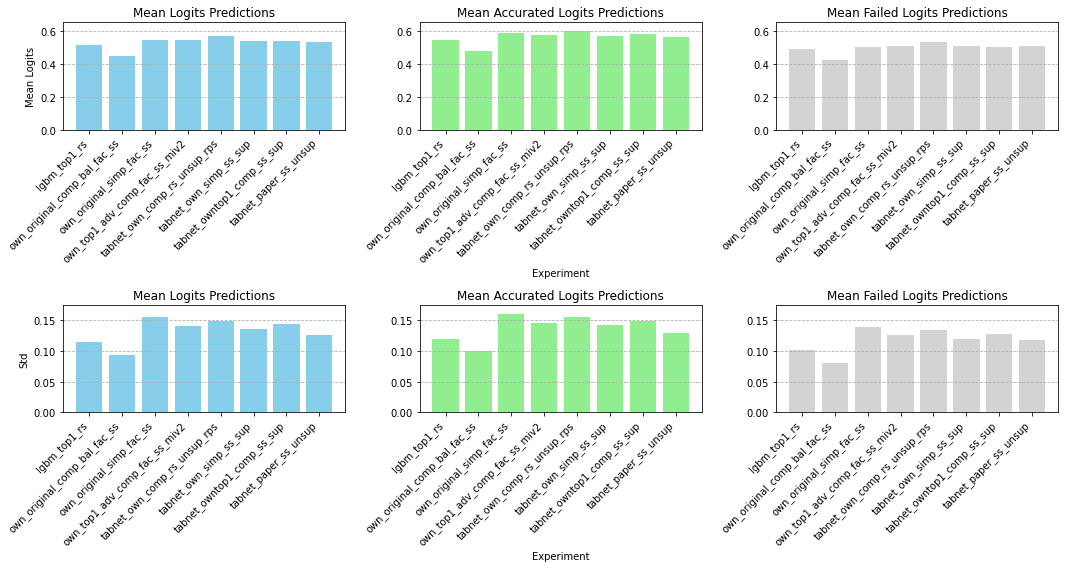

In [227]:
df1 = concat_merged.groupby('variable').logit.mean().to_frame()
df2 = concat_merged[concat_merged['class']==concat_merged.label].groupby('variable').logit.mean().to_frame()
df3 = concat_merged[concat_merged['class']!=concat_merged.label].groupby('variable').logit.mean().to_frame()

# Create a figure with two subplots (side by side)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))  # Adjusted figsize for better horizontal space

vmin, vmax = 0, pd.concat([df1,df2]).logit.max()+0.05

# Plot the first dataframe using plt.bar
ax = axes[0][0]
ax.bar(df1.index, df1['logit'], color='skyblue')
ax.set_title('Mean Logits Predictions')
ax.set_ylabel('Mean Logits')
ax.set_ylim(vmin, vmax)
ax.set_xticklabels(df1.index, rotation=45, ha='right')

# Plot the second dataframe using plt.bar
ax = axes[0][1]
ax.bar(df2.index, df2['logit'], color='lightgreen')
ax.set_title('Mean Accurated Logits Predictions')
ax.set_xlabel('Experiment')
ax.set_ylim(vmin, vmax)
ax.set_xticklabels(df2.index, rotation=45, ha='right')

# Plot the third dataframe using plt.bar
ax = axes[0][2]
ax.bar(df3.index, df3['logit'], color='lightgrey')
ax.set_title('Mean Failed Logits Predictions')
ax.set_ylim(vmin, vmax)
ax.set_xticklabels(df3.index, rotation=45, ha='right')

df1 = concat_merged.groupby('variable').logit.std().to_frame()
df2 = concat_merged[concat_merged['class']==concat_merged.label].groupby('variable').logit.std().to_frame()
df3 = concat_merged[concat_merged['class']!=concat_merged.label].groupby('variable').logit.std().to_frame()
vmin, vmax = 0, pd.concat([df1,df2,df3]).logit.max()+0.015

# Plot the first dataframe using plt.bar
ax = axes[1][0]
ax.bar(df1.index, df1['logit'], color='skyblue')
ax.set_title('Mean Logits Predictions')
ax.set_ylabel('Std')
ax.set_ylim(vmin, vmax)
ax.set_xticklabels(df1.index, rotation=45, ha='right')

# Plot the second dataframe using plt.bar
ax = axes[1][1]
ax.bar(df2.index, df2['logit'], color='lightgreen')
ax.set_title('Mean Accurated Logits Predictions')
ax.set_xlabel('Experiment')
ax.set_ylim(vmin, vmax)
ax.set_xticklabels(df2.index, rotation=45, ha='right')

# Plot the third dataframe using plt.bar
ax = axes[1][2]
ax.bar(df3.index, df3['logit'], color='lightgrey')
ax.set_title('Mean Failed Logits Predictions')
ax.set_ylim(vmin, vmax)
ax.set_xticklabels(df3.index, rotation=45, ha='right')


axes[0][0].grid(axis='y',linestyle='--')
axes[0][1].grid(axis='y',linestyle='--')
axes[0][2].grid(axis='y',linestyle='--')
axes[1][0].grid(axis='y',linestyle='--')
axes[1][1].grid(axis='y',linestyle='--')
axes[1][2].grid(axis='y',linestyle='--')
# Adjust layout to prevent overlap
plt.tight_layout()
# Save the figure
plt.savefig(PATH_GRAPHS+'mean_std_logits'+'.jpeg', bbox_inches='tight', dpi='figure')

# Show the plot
plt.show()

In [60]:
pivot_class = concat_merged.pivot(index=METADATA,columns='variable',values='logit').reset_index()
pivot_class

variable,match,Date,season,Div,HomeTeam,AwayTeam,FTHG,FTAG,label,lgbm_top1_rs,own_original_comp_bal_fac_ss,own_original_simp_fac_ss,own_top1_adv_comp_fac_ss_miv2,tabnet_own_comp_rs_unsup_rps,tabnet_own_simp_ss_sup,tabnet_owntop1_comp_ss_sup,tabnet_paper_ss_unsup
0,5967,2020-01-17,T19-20,D1,Schalke 04,M'gladbach,2,0,1,0.4518,NaN,NaN,NaN,NaN,NaN,NaN,0.6860
1,5968,2020-01-18,T19-20,D1,Augsburg,Dortmund,3,5,2,0.4367,NaN,NaN,NaN,NaN,NaN,NaN,0.5734
2,5969,2020-01-18,T19-20,D1,FC Koln,Wolfsburg,3,1,1,0.3660,NaN,NaN,NaN,NaN,NaN,NaN,0.3863
3,5970,2020-01-18,T19-20,D1,Fortuna Dusseldorf,Werder Bremen,0,1,2,0.4104,NaN,NaN,NaN,NaN,NaN,NaN,0.3998
4,5971,2020-01-18,T19-20,D1,Hoffenheim,Ein Frankfurt,1,2,2,0.5741,NaN,NaN,NaN,NaN,NaN,NaN,0.5359
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2588,45752,2021-05-22,T20-21,SP1,Osasuna,Sociedad,0,1,2,0.3596,0.4122,0.3993,0.4078,0.3508,0.3665,0.3621,0.3904
2589,45753,2021-05-22,T20-21,SP1,Real Madrid,Villarreal,2,1,1,0.5809,0.5089,0.6807,0.7532,0.8361,0.5903,0.5933,0.7168
2590,45754,2021-05-22,T20-21,SP1,Valladolid,Ath Madrid,1,2,2,0.5845,0.5496,0.7855,0.6350,0.5631,0.6206,0.6859,0.5543
2591,45755,2021-05-23,T20-21,SP1,Granada,Getafe,0,0,0,0.4388,0.3582,0.3954,0.3910,0.3519,0.4410,0.4067,0.3893


2020-01-01 00:00:00 2021-05-23 00:00:00


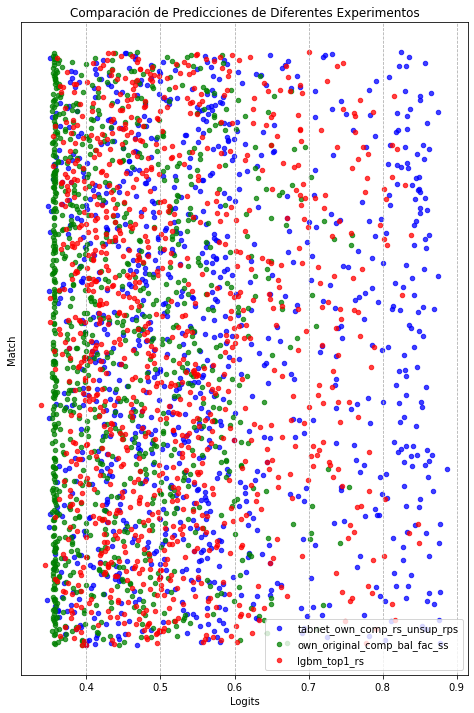

In [61]:
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'orange']

df = pivot_class.dropna().sample(1000,random_state=0).sort_values('Date').reset_index(drop=True)
print(df.Date.min(),df.Date.max())

plt.figure(figsize=(8, 12))

for i, experiment in enumerate(['tabnet_own_comp_rs_unsup_rps','own_original_comp_bal_fac_ss','lgbm_top1_rs']):
    plt.scatter(df[experiment], df.index, color=colors[i], label=experiment, s=20, alpha=0.75)
    
plt.ylabel('Match')
plt.xlabel('Logits')
plt.title('Comparación de Predicciones de Diferentes Experimentos')
plt.legend()
plt.yticks(ticks=[],labels=[], rotation=90)
plt.grid(axis='x',linestyle='--')
plt.grid(axis='y',linestyle='--')

plt.savefig(PATH_GRAPHS+'samples_pred_distribution.jpeg', bbox_inches='tight', dpi='figure')

plt.show()


In [62]:
df_logit_predclass = concat_merged
df_logit_predclass.loc[:,'dif_goals'] = df_logit_predclass.FTHG - df_logit_predclass.FTAG
df_logit_predclass

,match,Date,season,Div,HomeTeam,AwayTeam,FTHG,FTAG,label,variable,logit,class,dif_goals
0,15976,2020-01-01,T19-20,E0,West Ham,Bournemouth,4,0,1,own_original_comp_bal_fac_ss,0.3576,0,4
1,15970,2020-01-01,T19-20,E0,Burnley,Aston Villa,1,2,2,own_original_comp_bal_fac_ss,0.3580,0,-1
2,45177,2020-01-03,T19-20,SP1,Valladolid,Leganes,2,2,0,own_original_comp_bal_fac_ss,0.3565,0,0
3,45186,2020-01-05,T19-20,SP1,Celta,Osasuna,1,1,0,own_original_comp_bal_fac_ss,0.3564,0,0
4,45184,2020-01-05,T19-20,SP1,Sociedad,Villarreal,1,2,2,own_original_comp_bal_fac_ss,0.3551,0,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16619,16207,2020-10-26,T20-21,E0,Burnley,Tottenham,0,1,2,tabnet_own_comp_rs_unsup_rps,0.6448,2,-1
16620,35330,2020-11-01,T20-21,I1,Torino,Lazio,3,4,2,tabnet_own_comp_rs_unsup_rps,0.5182,2,-1
16621,16488,2021-05-08,T20-21,E0,Leeds,Tottenham,3,1,1,tabnet_own_comp_rs_unsup_rps,0.4753,2,2
16622,35634,2021-05-12,T20-21,I1,Torino,Milan,0,7,2,tabnet_own_comp_rs_unsup_rps,0.4911,2,-7


In [63]:
df_logit_predclass[df_logit_predclass.match==15973].sort_values(['variable','class'])

,match,Date,season,Div,HomeTeam,AwayTeam,FTHG,FTAG,label,variable,logit,class,dif_goals
463,15973,2020-01-01,T19-20,E0,Watford,Wolves,2,1,1,lgbm_top1_rs,0.3696,1,1
12207,15973,2020-01-01,T19-20,E0,Watford,Wolves,2,1,1,own_original_comp_bal_fac_ss,0.4373,2,1
13076,15973,2020-01-01,T19-20,E0,Watford,Wolves,2,1,1,own_original_simp_fac_ss,0.4382,2,1
13711,15973,2020-01-01,T19-20,E0,Watford,Wolves,2,1,1,own_top1_adv_comp_fac_ss_miv2,0.4370,2,1
15980,15973,2020-01-01,T19-20,E0,Watford,Wolves,2,1,1,tabnet_own_comp_rs_unsup_rps,0.4178,2,1
6739,15973,2020-01-01,T19-20,E0,Watford,Wolves,2,1,1,tabnet_own_simp_ss_sup,0.3657,1,1
14258,15973,2020-01-01,T19-20,E0,Watford,Wolves,2,1,1,tabnet_owntop1_comp_ss_sup,0.4503,2,1
8265,15973,2020-01-01,T19-20,E0,Watford,Wolves,2,1,1,tabnet_paper_ss_unsup,0.3929,1,1


0.0072124891681027755 0.230518450093118


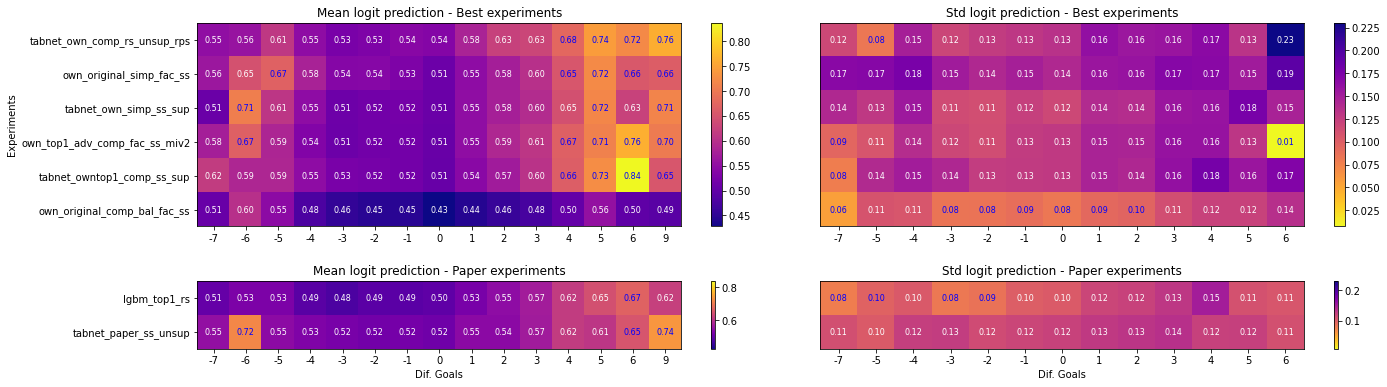

In [64]:
# DIF_RES

groupby = df_logit_predclass.groupby(['variable','dif_goals'])
matrix_mean = groupby.logit.mean().reset_index().pivot(index='variable',columns='dif_goals').T[top_experiments].dropna().reset_index(level=0, drop=True).T
matrix_std = groupby.logit.std().reset_index().pivot(index='variable',columns='dif_goals').T[top_experiments].dropna().reset_index(level=0, drop=True).T
matrix_mean_paper = groupby.logit.mean().reset_index().pivot(index='variable',columns='dif_goals').T[paper_exp].dropna().reset_index(level=0, drop=True).T
matrix_std_paper = groupby.logit.std().reset_index().pivot(index='variable',columns='dif_goals').T[paper_exp].dropna().reset_index(level=0, drop=True).T

# Define color map
color_maps = ['viridis', 'plasma', 'inferno', 'magma', 'cividis']
cmap = color_maps[1]
rps_min, rps_max = pd.concat([matrix_std,matrix_std_paper]).values.min(), pd.concat([matrix_std,matrix_std_paper]).values.max()
print(rps_min,rps_max)
acc_min, acc_max = pd.concat([matrix_mean,matrix_mean_paper]).values.min(), pd.concat([matrix_mean,matrix_mean_paper]).values.max()

# Define fixed height for each row
row_height = 0.75  # Adjust this value as needed
# Calculate the height for each subplot based on the number of rows
heights = [len(matrix_std), len(matrix_mean_paper)]  # Number of rows in each subplot
# Create the subplots with specified heights
fig, axes = plt.subplots(2, 2, figsize=(22, sum(heights) * row_height), 
                         gridspec_kw={'height_ratios': heights})
plt.subplots_adjust(hspace=0.4, wspace=0.03)

def add_numbers_to_heatmap(matrix, ax, color_func=lambda v: 'blue' if v>0.65 else 'white'):
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            text = ax.text(j, i, f'{matrix.iloc[i, j]:.2f}',
                           ha='center', va='center', color=color_func(matrix.iloc[i, j]), fontsize=8)

# Plot first heatmap
cax1 = axes[0][0].imshow(matrix_mean, cmap=cmap, aspect='auto',vmin=acc_min, vmax=acc_max)
add_numbers_to_heatmap(matrix_mean, axes[0][0])
axes[0][0].set_title('Mean logit prediction - Best experiments')
axes[0][0].set_ylabel('Experiments')
axes[0][0].set_xticks(np.arange(len(matrix_mean.columns)))
axes[0][0].set_xticklabels(matrix_mean.columns, rotation=0)
axes[0][0].set_yticks(np.arange(len(matrix_mean)))
axes[0][0].set_yticklabels(map(lambda x: x.replace('accurate_flag_',''),matrix_mean.index))
fig.colorbar(cax1, ax=axes[0][0])

# Plot second heatmap
cax2 = axes[0][1].imshow(matrix_std, cmap=cmap+'_r', aspect='auto',vmin=rps_min, vmax=rps_max)
add_numbers_to_heatmap(matrix_std, axes[0][1],color_func=lambda v: 'blue' if v<0.1 else 'white')
axes[0][1].set_title('Std logit prediction - Best experiments')
axes[0][1].set_xticks(np.arange(len(matrix_std.columns)))
axes[0][1].set_xticklabels(matrix_std.columns, rotation=0)
axes[0][1].set_yticks([])
fig.colorbar(cax2, ax=axes[0][1])

# Plot first heatmap
cax3 = axes[1][0].imshow(matrix_mean_paper, cmap=cmap, aspect='auto',vmin=acc_min, vmax=acc_max)
add_numbers_to_heatmap(matrix_mean_paper, axes[1][0])
axes[1][0].set_title('Mean logit prediction - Paper experiments')
axes[0][0].set_ylabel('Experiments')
axes[1][0].set_xlabel('Dif. Goals')
axes[1][0].set_xticks(np.arange(len(matrix_mean_paper.columns)))
axes[1][0].set_xticklabels(matrix_mean_paper.columns, rotation=0)
axes[1][0].set_yticks(np.arange(len(matrix_mean_paper)))
axes[1][0].set_yticklabels(map(lambda x: x.replace('accurate_flag_',''),matrix_mean_paper.index))
fig.colorbar(cax3, ax=axes[1][0])

# Plot second heatmap
cax4 = axes[1][1].imshow(matrix_std_paper, cmap=cmap+'_r', aspect='auto', vmin=rps_min, vmax=rps_max)
add_numbers_to_heatmap(matrix_std_paper, axes[1][1],color_func=lambda v: 'blue' if v<0.1 else 'white')
axes[1][1].set_title('Std logit prediction - Paper experiments')
axes[1][1].set_xlabel('Dif. Goals')
axes[1][1].set_xticks(np.arange(len(matrix_std_paper.columns)))
axes[1][1].set_xticklabels(matrix_std_paper.columns, rotation=0)
axes[1][1].set_yticks([])
fig.colorbar(cax4, ax=axes[1][1])

plt.savefig(PATH_GRAPHS+'difgoals_logit_pred_meanstd.jpeg', bbox_inches='tight', dpi='figure')
plt.show()

##### Dist. logits

In [233]:
melt_concat[melt_concat.match==15976]

,match,Date,season,Div,HomeTeam,AwayTeam,FTHG,FTAG,label,variable,logit,class
6,15976,2020-01-01,T19-20,E0,West Ham,Bournemouth,4,0,1.0,lgbm_top1_rs,0.2839,0
2599,15976,2020-01-01,T19-20,E0,West Ham,Bournemouth,4,0,1.0,own_original_comp_bal_fac_ss,0.3576,0
5192,15976,2020-01-01,T19-20,E0,West Ham,Bournemouth,4,0,1.0,own_original_simp_fac_ss,0.3337,0
7785,15976,2020-01-01,T19-20,E0,West Ham,Bournemouth,4,0,1.0,own_top1_adv_comp_fac_ss_miv2,0.3029,0
10378,15976,2020-01-01,T19-20,E0,West Ham,Bournemouth,4,0,1.0,tabnet_owntop1_comp_ss_sup,0.2653,0
12971,15976,2020-01-01,T19-20,E0,West Ham,Bournemouth,4,0,1.0,tabnet_own_simp_ss_sup,0.2787,0
15564,15976,2020-01-01,T19-20,E0,West Ham,Bournemouth,4,0,1.0,tabnet_paper_ss_unsup,0.2879,0
18157,15976,2020-01-01,T19-20,E0,West Ham,Bournemouth,4,0,1.0,tabnet_own_comp_rs_unsup_rps,0.3038,0
6,15976,2020-01-01,T19-20,E0,West Ham,Bournemouth,4,0,1.0,lgbm_top1_rs,0.4375,1
2599,15976,2020-01-01,T19-20,E0,West Ham,Bournemouth,4,0,1.0,own_original_comp_bal_fac_ss,0.3215,1


In [274]:
melt_concat.groupby(METADATA+['variable']).logit.std().reset_index().pivot(index=METADATA,columns='variable',values='logit').mean().to_frame()

,0
variable,
lgbm_top1_rs,0.162040
own_original_comp_bal_fac_ss,0.113570
own_original_simp_fac_ss,0.190755
own_top1_adv_comp_fac_ss_miv2,0.185982
tabnet_own_comp_rs_unsup_rps,0.205840
tabnet_own_simp_ss_sup,0.184613
tabnet_owntop1_comp_ss_sup,0.183003
tabnet_paper_ss_unsup,0.178376


<ipython-input-280-15760c2ab967>:14: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(df1.index, rotation=45, ha='right')


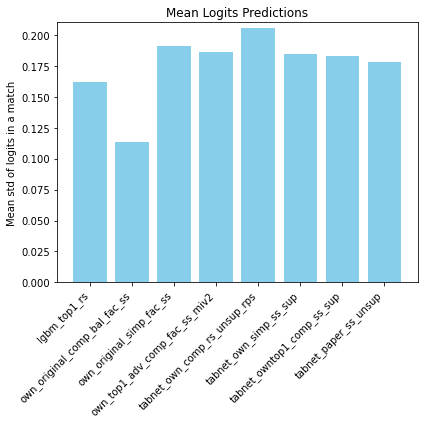

In [280]:
df1 = melt_concat.groupby(METADATA+['variable']).logit.std().reset_index().pivot(index=METADATA,columns='variable',values='logit').mean().to_frame()

column = df1.columns[0]
# Create a figure with two subplots (side by side)
fig, ax = plt.subplots(1, 1, figsize=(6, 6))  # Adjusted figsize for better horizontal space

vmin, vmax = 0, pd.concat([df1,df2]).logit.max()+0.05

# Plot the first dataframe using plt.bar
ax.bar(df1.index, df1[column], color='skyblue')
ax.set_title('Mean Logits Predictions')
ax.set_ylabel('Mean std of logits in a match')
ax.set_ylim(vmin, vmax)
ax.set_xticklabels(df1.index, rotation=45, ha='right')

axes[0][0].grid(axis='y',linestyle='--')

# Adjust layout to prevent overlap
plt.tight_layout()
# Save the figure
plt.savefig(PATH_GRAPHS+'std_logits'+'.jpeg', bbox_inches='tight', dpi='figure')

# Show the plot
plt.show()

### INDIVIDUAL MATCH

Buscar partidos que tengan resultados (logits y/o predicciones) muy diferentes entre el paper y nuestros modelos
Dando preferencia a partidos que nosotros acertemos y ellos no

In [26]:
melt_rps = logits_topleagues.melt(id_vars=METADATA, value_vars=[col for col in logits_topleagues.columns if col.startswith('rps')]).rename(columns={'value':'rps'})
melt_rps.loc[:,'variable'] = melt_rps.variable.apply(lambda c: '_'.join(c.split('_')[1:]))
melt_rps

,match,Date,season,Div,HomeTeam,AwayTeam,FTHG,FTAG,label,variable,rps
0,15969,2020-01-01,T19-20,E0,Brighton,Chelsea,1,1,0.0,lgbm_top1_rs,0.402361
1,15971,2020-01-01,T19-20,E0,Newcastle,Leicester,0,3,2.0,lgbm_top1_rs,0.218283
2,15972,2020-01-01,T19-20,E0,Southampton,Tottenham,1,0,1.0,lgbm_top1_rs,0.163995
3,15973,2020-01-01,T19-20,E0,Watford,Wolves,2,1,1.0,lgbm_top1_rs,0.100803
4,15974,2020-01-01,T19-20,E0,Man City,Everton,2,1,1.0,lgbm_top1_rs,0.018181
...,...,...,...,...,...,...,...,...,...,...,...
20739,6202,2020-12-05,T20-21,D1,Bielefeld,Mainz,2,1,1.0,tabnet_own_comp_rs_unsup_rps,NaN
20740,35366,2020-12-05,T20-21,I1,Spezia,Lazio,1,2,2.0,tabnet_own_comp_rs_unsup_rps,NaN
20741,45487,2020-12-06,T20-21,SP1,Villarreal,Elche,0,0,0.0,tabnet_own_comp_rs_unsup_rps,NaN
20742,35372,2020-12-06,T20-21,I1,Crotone,Napoli,0,4,2.0,tabnet_own_comp_rs_unsup_rps,NaN


In [27]:
concat_merged = (pd.merge(melt_concat,melt_pred.rename(columns={'class':'pred'}),on=METADATA+['variable'])
                    .merge(melt_rps,on=METADATA+['variable'])
                    .drop_duplicates()
                )
concat_merged.label = concat_merged.label.astype(int)
concat_merged

,match,Date,season,Div,HomeTeam,AwayTeam,FTHG,FTAG,label,variable,logit,class,pred,rps
0,15969,2020-01-01,T19-20,E0,Brighton,Chelsea,1,1,0,lgbm_top1_rs,0.2546,0,2,0.402361
1,15969,2020-01-01,T19-20,E0,Brighton,Chelsea,1,1,0,lgbm_top1_rs,0.2463,1,2,0.402361
2,15969,2020-01-01,T19-20,E0,Brighton,Chelsea,1,1,0,lgbm_top1_rs,0.4991,2,2,0.402361
3,15971,2020-01-01,T19-20,E0,Newcastle,Leicester,0,3,2,lgbm_top1_rs,0.2754,0,2,0.218283
4,15971,2020-01-01,T19-20,E0,Newcastle,Leicester,0,3,2,lgbm_top1_rs,0.3252,1,2,0.218283
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49867,35632,2021-05-12,T20-21,I1,Sampdoria,Spezia,2,2,0,tabnet_own_comp_rs_unsup_rps,0.6702,1,1,0.323800
49868,35632,2021-05-12,T20-21,I1,Sampdoria,Spezia,2,2,0,tabnet_own_comp_rs_unsup_rps,0.1248,2,1,0.323800
49869,35627,2021-05-12,T20-21,I1,Cagliari,Fiorentina,0,0,0,tabnet_own_comp_rs_unsup_rps,0.2903,0,1,0.283438
49870,35627,2021-05-12,T20-21,I1,Cagliari,Fiorentina,0,0,0,tabnet_own_comp_rs_unsup_rps,0.4583,1,1,0.283438


In [47]:
isAcc = (concat_merged.pred==concat_merged.label)
isRPS =  concat_merged.variable == 'tabnet_own_comp_rs_unsup_rps'
isSOTA2 = concat_merged.variable == 'lgbm_top1_rs'

In [61]:
# match_comp = pd.merge(concat_merged[isRPS & isAcc], concat_merged[isSOTA2], on=METADATA+['class'])
match_comp = pd.merge(concat_merged[isRPS & isAcc], concat_merged[isSOTA2 & ~isAcc], on=METADATA+['class'])
dict_renames = { 
                    **{ col:col[:-2]+'_own' for col in match_comp if '_x' in col}, 
                    **{ col:col[:-2]+'_sota' for col in match_comp if '_y' in col}, 
                }
match_comp = match_comp.rename(columns=dict_renames)
match_comp

,match,Date,season,Div,HomeTeam,AwayTeam,FTHG,FTAG,label,variable_own,logit_own,class,pred_own,rps_own,variable_sota,logit_sota,pred_sota,rps_sota
0,45200,2020-01-25,T19-20,SP1,Alaves,Villarreal,1,2,2,tabnet_own_comp_rs_unsup_rps,0.2890,0,2,0.212873,lgbm_top1_rs,0.3112,1,0.287993
1,45200,2020-01-25,T19-20,SP1,Alaves,Villarreal,1,2,2,tabnet_own_comp_rs_unsup_rps,0.2960,1,2,0.212873,lgbm_top1_rs,0.3810,1,0.287993
2,45200,2020-01-25,T19-20,SP1,Alaves,Villarreal,1,2,2,tabnet_own_comp_rs_unsup_rps,0.4150,2,2,0.212873,lgbm_top1_rs,0.3078,1,0.287993
3,35097,2020-01-25,T19-20,I1,Spal,Bologna,1,3,2,tabnet_own_comp_rs_unsup_rps,0.2959,0,2,0.241788,lgbm_top1_rs,0.2955,1,0.304663
4,35097,2020-01-25,T19-20,I1,Spal,Bologna,1,3,2,tabnet_own_comp_rs_unsup_rps,0.3334,1,2,0.241788,lgbm_top1_rs,0.4270,1,0.304663
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217,45746,2021-05-16,T20-21,SP1,Villarreal,Sevilla,4,0,1,tabnet_own_comp_rs_unsup_rps,0.4219,1,1,0.083641,lgbm_top1_rs,0.2941,2,0.130131
218,45746,2021-05-16,T20-21,SP1,Villarreal,Sevilla,4,0,1,tabnet_own_comp_rs_unsup_rps,0.2795,2,1,0.083641,lgbm_top1_rs,0.4275,2,0.130131
219,45752,2021-05-22,T20-21,SP1,Osasuna,Sociedad,0,1,2,tabnet_own_comp_rs_unsup_rps,0.3029,0,2,0.256669,lgbm_top1_rs,0.2845,1,0.247903
220,45752,2021-05-22,T20-21,SP1,Osasuna,Sociedad,0,1,2,tabnet_own_comp_rs_unsup_rps,0.3464,1,2,0.256669,lgbm_top1_rs,0.3596,1,0.247903


In [62]:
match_comp.loc[:,'dif_res'] = match_comp.rps_own - match_comp.rps_sota
match_comp = match_comp.sort_values('dif_res')
match_comp

,match,Date,season,Div,HomeTeam,AwayTeam,FTHG,FTAG,label,variable_own,logit_own,class,pred_own,rps_own,variable_sota,logit_sota,pred_sota,rps_sota,dif_res
56,6180,2020-11-07,T20-21,D1,Dortmund,Bayern Munich,2,3,2,tabnet_own_comp_rs_unsup_rps,0.6571,2,2,0.077338,lgbm_top1_rs,0.3037,1,0.269375,-0.192038
55,6180,2020-11-07,T20-21,D1,Dortmund,Bayern Munich,2,3,2,tabnet_own_comp_rs_unsup_rps,0.1503,1,2,0.077338,lgbm_top1_rs,0.4645,1,0.269375,-0.192038
54,6180,2020-11-07,T20-21,D1,Dortmund,Bayern Munich,2,3,2,tabnet_own_comp_rs_unsup_rps,0.1926,0,2,0.077338,lgbm_top1_rs,0.2319,1,0.269375,-0.192038
190,6359,2021-04-03,T20-21,D1,RB Leipzig,Bayern Munich,0,1,2,tabnet_own_comp_rs_unsup_rps,0.1703,1,2,0.096025,lgbm_top1_rs,0.4208,1,0.278234,-0.182209
189,6359,2021-04-03,T20-21,D1,RB Leipzig,Bayern Munich,0,1,2,tabnet_own_comp_rs_unsup_rps,0.2128,0,2,0.096025,lgbm_top1_rs,0.2733,1,0.278234,-0.182209
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184,35546,2021-03-20,T20-21,I1,Crotone,Bologna,2,3,2,tabnet_own_comp_rs_unsup_rps,0.3197,1,2,0.237750,lgbm_top1_rs,0.3785,1,0.232375,0.005376
183,35546,2021-03-20,T20-21,I1,Crotone,Bologna,2,3,2,tabnet_own_comp_rs_unsup_rps,0.3008,0,2,0.237750,lgbm_top1_rs,0.2541,1,0.232375,0.005376
220,45752,2021-05-22,T20-21,SP1,Osasuna,Sociedad,0,1,2,tabnet_own_comp_rs_unsup_rps,0.3464,1,2,0.256669,lgbm_top1_rs,0.3596,1,0.247903,0.008767
219,45752,2021-05-22,T20-21,SP1,Osasuna,Sociedad,0,1,2,tabnet_own_comp_rs_unsup_rps,0.3029,0,2,0.256669,lgbm_top1_rs,0.2845,1,0.247903,0.008767


In [58]:
isLabel = match_comp['class'] == match_comp['label']
isDisputed = match_comp['logit_own']<0.45
match_comp = match_comp[isLabel & isDisputed]
match_comp.sort_values('logit_own')

,match,Date,season,Div,HomeTeam,AwayTeam,FTHG,FTAG,label,variable_own,logit_own,class,pred_own,rps_own,variable_sota,logit_sota,pred_sota,rps_sota,dif_res
194,26609,2020-02-01,T19-20,F1,Angers,Reims,1,4,2,tabnet_own_comp_rs_unsup_rps,0.3473,2,2,0.260256,lgbm_top1_rs,0.2486,1,0.329795,-0.069539
1018,16279,2020-12-19,T20-21,E0,Everton,Arsenal,2,1,1,tabnet_own_comp_rs_unsup_rps,0.3491,1,1,0.106308,lgbm_top1_rs,0.5079,1,0.061486,0.044822
1862,35510,2021-02-28,T20-21,I1,Crotone,Cagliari,0,2,2,tabnet_own_comp_rs_unsup_rps,0.3503,2,2,0.258614,lgbm_top1_rs,0.3349,1,0.255711,0.002903
2696,45752,2021-05-22,T20-21,SP1,Osasuna,Sociedad,0,1,2,tabnet_own_comp_rs_unsup_rps,0.3508,2,2,0.256669,lgbm_top1_rs,0.3559,1,0.247903,0.008767
1957,45626,2021-03-06,T20-21,SP1,Valladolid,Getafe,2,1,1,tabnet_own_comp_rs_unsup_rps,0.3519,1,1,0.105229,lgbm_top1_rs,0.4260,1,0.082370,0.022859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1612,26902,2021-02-06,T20-21,F1,Lorient,Reims,1,0,1,tabnet_own_comp_rs_unsup_rps,0.4476,1,1,0.076784,lgbm_top1_rs,0.3702,1,0.101682,-0.024898
923,45492,2020-12-12,T20-21,SP1,Getafe,Sevilla,0,1,2,tabnet_own_comp_rs_unsup_rps,0.4482,2,2,0.191051,lgbm_top1_rs,0.3521,2,0.254111,-0.063060
2506,16480,2021-05-01,T20-21,E0,Brighton,Leeds,2,0,1,tabnet_own_comp_rs_unsup_rps,0.4483,1,1,0.076215,lgbm_top1_rs,0.3662,1,0.102406,-0.026191
2282,35572,2021-04-11,T20-21,I1,Verona,Lazio,0,1,2,tabnet_own_comp_rs_unsup_rps,0.4494,2,2,0.190418,lgbm_top1_rs,0.5047,2,0.153314,0.037104


In [63]:
sel_cols = METADATA + [ col for col in logits_topleagues.columns if 'lgbm_top1_rs' in col or 'tabnet_own_comp_rs_unsup_rps' in col ]
sel_cols

['match',
 'Date',
 'season',
 'Div',
 'HomeTeam',
 'AwayTeam',
 'FTHG',
 'FTAG',
 'label',
 'prediction_lgbm_top1_rs',
 'draw_lgbm_top1_rs',
 'home_lgbm_top1_rs',
 'away_lgbm_top1_rs',
 'prediction_tabnet_own_comp_rs_unsup_rps',
 'draw_tabnet_own_comp_rs_unsup_rps',
 'home_tabnet_own_comp_rs_unsup_rps',
 'away_tabnet_own_comp_rs_unsup_rps',
 'accurate_flag_lgbm_top1_rs',
 'rps_lgbm_top1_rs',
 'accurate_flag_tabnet_own_comp_rs_unsup_rps',
 'rps_tabnet_own_comp_rs_unsup_rps']

In [65]:
match_comp.match.unique()

array([ 6180,  6359,  6056, 16364, 45617, 16344, 16336,  6253, 16372,
        6229, 16220,  6234, 26816, 16312, 45513, 26659, 35356, 45262,
        6034, 45598, 35575, 16012, 16379,  6275, 16337, 45482, 35507,
       45200, 45602, 35403, 27032, 26609,  6310, 16431, 45550, 35553,
        6110, 26822, 16203, 35097, 45621,  6107, 35105, 27028,  6407,
       26866,  6223, 16461, 45530, 16015, 35132, 45746,  6330,  6265,
       35537, 26838, 35450, 16041, 35484, 26628, 35445, 26996,  6273,
       26966, 16450, 35599,  5995, 16416,  6295, 26967, 45505, 35510,
       35546, 45752], dtype=int64)

In [71]:
__compare_res = logits_topleagues[logits_topleagues.match.isin(match_comp.match.unique())][sel_cols]
rename_cols = [ col.replace('tabnet_own_comp_rs_unsup_rps','own').replace('lgbm_top1_rs','sota') for col in __compare_res.columns ]
print(rename_cols)
__compare_res.columns = rename_cols
__compare_res.loc[:,'dif_res'] = __compare_res.rps_own - __compare_res.rps_sota
__compare_res

['match', 'Date', 'season', 'Div', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'label', 'prediction_sota', 'draw_sota', 'home_sota', 'away_sota', 'prediction_own', 'draw_own', 'home_own', 'away_own', 'accurate_flag_sota', 'rps_sota', 'accurate_flag_own', 'rps_own']


,match,Date,season,Div,HomeTeam,AwayTeam,FTHG,FTAG,label,prediction_sota,...,away_sota,prediction_own,draw_own,home_own,away_own,accurate_flag_sota,rps_sota,accurate_flag_own,rps_own,dif_res
156,45200,2020-01-25,T19-20,SP1,Alaves,Villarreal,1,2,2.0,1.0,...,0.3078,2.0,0.2890,0.2960,0.4150,0.0,0.287993,1.0,0.212873,-0.075120
163,35097,2020-01-25,T19-20,I1,Spal,Bologna,1,3,2.0,1.0,...,0.2776,2.0,0.2959,0.3334,0.3707,0.0,0.304663,1.0,0.241788,-0.062876
175,35105,2020-01-26,T19-20,I1,Napoli,Juventus,2,1,1.0,2.0,...,0.4929,1.0,0.2862,0.3733,0.3404,0.0,0.152476,1.0,0.098925,-0.053550
206,16015,2020-02-01,T19-20,E0,Watford,Everton,2,3,2.0,1.0,...,0.3088,2.0,0.3013,0.3193,0.3794,0.0,0.285582,1.0,0.237963,-0.047619
209,16012,2020-02-01,T19-20,E0,Crystal Palace,Sheffield United,0,1,2.0,1.0,...,0.2743,2.0,0.2977,0.3167,0.3856,0.0,0.315978,1.0,0.233056,-0.082922
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2335,27028,2021-05-09,T20-21,F1,St Etienne,Marseille,1,0,1.0,2.0,...,0.4403,1.0,0.2950,0.4359,0.2691,0.0,0.132496,1.0,0.079720,-0.052777
2354,27032,2021-05-09,T20-21,F1,Strasbourg,Montpellier,2,3,2.0,1.0,...,0.2697,2.0,0.2944,0.3249,0.3807,0.0,0.305534,1.0,0.235102,-0.070432
2364,6407,2021-05-12,T20-21,D1,Schalke 04,Hertha,1,2,2.0,1.0,...,0.3275,2.0,0.2884,0.2916,0.4199,0.0,0.261773,1.0,0.209787,-0.051985
2379,45746,2021-05-16,T20-21,SP1,Villarreal,Sevilla,4,0,1.0,2.0,...,0.4275,1.0,0.2986,0.4219,0.2795,0.0,0.130131,1.0,0.083641,-0.046490


In [70]:
__compare_res.match.head(20).to_numpy()

array([45200, 35097, 35105, 16015, 16012, 26609,  5995, 26628, 35132,
       16041, 26659,  6034, 45262,  6056,  6107,  6110, 16203, 16220,
        6180, 35356], dtype=int64)

In [46]:
ut.save_dataframe(__compare_res,'F:\\TFG\\code\\framework\\logs\\',name_of_file='__compare_res_2')

## end